# Data Mining Project

## 1. Data Preprocessing & Exploration

In [ ]:
#import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

url = "https://raw.githubusercontent.com/YazidShariful/dataset/main/Marital%20satisfaction_Data.xlsx"
df = pd.read_excel(url)


df.head()

,Country,"Sex (1-M, 2-F)",Age,Marriage duration (years),Number of children,Number of brought up children,"Education (1-no formal education, 2-primary school, 3-secondary school, 4-high school or technical college, 5-bachelor or master degree)","Material status (1-much better than average in my country, 2-better than average in my country, 3-similar to average in my country, 4-worse than average in my country, 5-much worse than average in my country)","Religion (1-Protestant, 2-Catholic, 3-Jewish, 4-Muslim, 5-Buddhist, 6-None, 7-Jehovah, 8-Evangelic, 9-Spiritualism, 10-Other - very specific, 11-Orthodox, 12-Hinduism)","Religiosity (1-not religious at all, 7-extremely religious)",...,Unnamed: 21,Unnamed: 22,"Collectivism-Individualism (GLOBE survey) (1-strongly agree, 4-neither agree nor disagree, 7-strongly disagree)",Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30
0,Item number,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,21.0,22.0,1,2.0,3.0,4.0,1,2.0,3.0,4.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,National level,NaN,NaN,NaN,Individual level,NaN,NaN,NaN
2,Brazil,1.0,21.0,2.0,0.0,0.0,5.0,3.0,1.0,4.0,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
3,Brazil,1.0,29.0,3.0,1.0,0.0,5.0,3.0,1.0,6.0,...,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0
4,Brazil,1.0,30.0,7.0,0.0,0.0,5.0,3.0,1.0,4.0,...,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0


In [ ]:
# Define clean column names
clean_names = [
    'Country', 'Sex', 'Age', 'MarriageDuration', 'NumChildren', 'NumRaised', 'Education',
    'Physio', 'Religion', 'Religiosity', 'Safety',
    'Love1', 'Happy', 'Esteem1', 'Love2', 'Love3', 'SelfAct', 'Esteem2', 'Love4', 'Love5',
    'MS1', 'MS2', 'MS3',
    'ParentAC-S', 'ChildAP-S', 'ParentsLWC-S', 'ChildLWP-S',
    'ParentAC-I', 'ChildAP-I', 'ParentsLWC-I', 'ChildLWP-I'
]




# Read the Excel file without header and drop metadata rows
df = (
    pd.read_excel(url, header=None, engine='openpyxl')
    .iloc[3:]                      # Skip first 3 metadata rows
    .reset_index(drop=True)       # Reset index
)
df.columns = clean_names          # Apply clean headers

# Convert columns to numeric where possible
df = df.apply(pd.to_numeric, errors='ignore')

df['Sex'] = df['Sex'].map({1: 'Male', 2: 'Female'})
df['Religion'] = df['Religion'].map({1: 'Protestant', 2: 'Catholic', 3: 'Jewish', 4: 'Muslim', 5: 'Buddhist', 6: 'None', 7: 'Jehovah', 8: 'Evangelic', 9: 'Spiritualism', 10: 'Other', 11: 'Orthodox', 12: 'Hinduism'})

# Preview the cleaned dataframe
df.head()

,Country,Sex,Age,MarriageDuration,NumChildren,NumRaised,Education,Physio,Religion,Religiosity,...,MS2,MS3,ParentAC-S,ChildAP-S,ParentsLWC-S,ChildLWP-S,ParentAC-I,ChildAP-I,ParentsLWC-I,ChildLWP-I
0,Brazil,Male,21.0,2.0,0,0,5,3,Protestant,4,...,7.0,7.0,1,1.0,1.0,1.0,1,1.0,1.0,1.0
1,Brazil,Male,29.0,3.0,1,0,5,3,Protestant,6,...,6.0,6.0,2,1.0,1.0,1.0,1,1.0,1.0,1.0
2,Brazil,Male,30.0,7.0,0,0,5,3,Protestant,4,...,7.0,7.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0
3,Brazil,Male,30.0,7.0,1,1,5,3,Protestant,6,...,6.0,6.0,3,1.0,1.0,2.0,1,1.0,1.0,1.0
4,Brazil,Male,28.0,9.0,0,0,4,2,Protestant,5,...,6.0,7.0,3,2.0,3.0,2.0,1,1.0,1.0,1.0


In [ ]:
df.isnull().sum()

,0
Country,0
Sex,0
Age,0
MarriageDuration,0
NumChildren,0
NumRaised,0
Education,0
Physio,0
Religion,86
Religiosity,0


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Country,0
Sex,0
Age,0
MarriageDuration,0
NumChildren,0
NumRaised,0
Education,0
Physio,0
Religion,0
Religiosity,0


In [ ]:
df.duplicated().sum()

np.int64(55)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Country,object
Sex,object
Age,float64
MarriageDuration,float64
NumChildren,int64
NumRaised,int64
Education,int64
Physio,int64
Religion,object
Religiosity,int64


In [ ]:
print(df.shape)

(7037, 31)


In [ ]:
nominal_cols = ['Country', 'Sex', 'Religion']  # Replace with your actual nominal columns

for col in nominal_cols:
    df[col] = df[col].astype('category')


## 2. Feature Engineering

In [ ]:
df['TotalChildren'] = df['NumChildren'] + df['NumRaised']


In [ ]:
#Convert ordinal to categorical
from pandas.api.types import CategoricalDtype

# 1. Define your ordinal scales
ord5 = [1, 2, 3, 4, 5]
ord7 = [1, 2, 3, 4, 5, 6, 7]
ord5_type = CategoricalDtype(categories=ord5, ordered=True)
ord7_type = CategoricalDtype(categories=ord7, ordered=True)

# 2. Normal 5-point ordinal (no flip needed)
normal_5 = ['Education']  # add any other true 1–5 ordinals here
for col in normal_5:
    df[col] = df[col].round().astype(int).astype(ord5_type)

# 3. Reverse-coded 5-point ordinal: flip then convert
reverse_5 = [
    'Physio','Love1','Love2','Love3','Love4','Love5',
    'Esteem1','SelfAct','Esteem2','Happy'
]
for col in reverse_5:
    df[col] = (6 - df[col]).round().astype(int).astype(ord5_type)

# 4. Normal 7-point ordinal (no flip needed)
normal_7 = ['Religiosity','MS1','MS2','MS3']
for col in normal_7:
    df[col] = df[col].round().astype(int).astype(ord7_type)

# 5. Reverse-coded 7-point ordinal: flip then convert
reverse_7 = [
    'Safety','ParentAC-S','ChildAP-S','ParentsLWC-S','ChildLWP-S',
    'ParentAC-I','ChildAP-I','ParentsLWC-I','ChildLWP-I'
]
for col in reverse_7:
    df[col] = (8 - df[col]).round().astype(int).astype(ord7_type)

# 6. Quick check
#print(df[ normal_5 + reverse_5 + normal_7 + reverse_7 ].dtypes)
df.dtypes


,0
Country,category
Sex,category
Age,float64
MarriageDuration,float64
NumChildren,int64
NumRaised,int64
Education,category
Physio,category
Religion,category
Religiosity,category


In [ ]:
# Age groups (unchanged)
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[17, 25, 35, 45, 60, 100],
    labels=['18-25', '26-35', '36-45', '46-60', '60+']
).astype('category')

# Marriage duration groups (unchanged)
df['MarriageGroup'] = pd.cut(
    df['MarriageDuration'],
    bins=[-1, 5, 10, 20, 50],
    labels=['0-5', '6-10', '11-20', '21+']
).astype('category')

# Total children groups: 0–1, 2–3, 4–5, and 6 or more
max_children = df['TotalChildren'].max()
df['ChildrenGroup'] = pd.cut(
    df['TotalChildren'],
    bins=[-1, 1, 3, 5, max_children],
    labels=['0-1', '2-3', '4-5', '6+']
).astype('category')

# Check the new categories
print(df[['AgeGroup', 'MarriageGroup', 'ChildrenGroup']].head())
print(df[['AgeGroup', 'MarriageGroup', 'ChildrenGroup']].dtypes)


  AgeGroup MarriageGroup ChildrenGroup
0    18-25           0-5           0-1
1    26-35           0-5           0-1
2    26-35          6-10           0-1
3    26-35          6-10           2-3
4    26-35          6-10           0-1
AgeGroup         category
MarriageGroup    category
ChildrenGroup    category
dtype: object


In [ ]:
cols_to_drop = ['Age', 'MarriageDuration', 'TotalChildren', 'NumChildren', 'NumRaised']
df.drop(cols_to_drop, axis=1, inplace=True)
df.dtypes

,0
Country,category
Sex,category
Education,category
Physio,category
Religion,category
Religiosity,category
Safety,category
Love1,category
Happy,category
Esteem1,category


In [ ]:
# 1. Find best MS by Spearman correlation with 'Happy'
from scipy.stats import spearmanr

ms_cols = ['MS1','MS2','MS3']
corrs = {}
for col in ms_cols:
    # cat.codes turns ordered categorical into integers
    corr, _ = spearmanr(df[col].cat.codes, df['Happy'].cat.codes)
    corrs[col] = corr

# Which MS has the highest absolute correlation?
best_ms = max(corrs, key=lambda x: abs(corrs[x]))
print("Spearman correlations with Happy:", corrs)
print("→ Best MS to use as target:", best_ms)


# 2. Love1–5 & Esteem1–3: keep them all as features.
#    We don’t need to “pick” among them now, because our RF feature-importance
#    in step 3 will tell us which of those (and every other feature) matters most.


# 3. Train a RandomForestClassifier to get feature importances
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# Define target
y = df[best_ms].cat.codes

# Define feature matrix X: drop the three MS cols
X = df.drop(columns=ms_cols + ['Country'])

# One-hot encode all categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Split & train
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Extract importances
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns)
importances = importances.sort_values(ascending=False)

# Build your three feature groups
all_features  =    X_encoded.columns.tolist()
top10_features = importances.head(10).index.tolist()
top3_features  = importances.head(3).index.tolist()

print("All features count:", len(all_features))
print("Top 10 features:", top10_features)
print("Top  3 features:", top3_features)

# Bundle into a dict for easy looping later
feature_groups = {
    'all_features': all_features,
    'top10_features': top10_features,
    'top3_features': top3_features
}

print(df.dtypes)

Spearman correlations with Happy: {'MS1': np.float64(0.5116127542323925), 'MS2': np.float64(0.5058543998690092), 'MS3': np.float64(0.5079642436799081)}
→ Best MS to use as target: MS1
All features count: 126
Top 10 features: ['Love4_5', 'Happy_5', 'Esteem2_5', 'Love1_5', 'Esteem1_5', 'Sex_Male', 'Love2_5', 'Love3_5', 'Happy_4', 'Love5_5']
Top  3 features: ['Love4_5', 'Happy_5', 'Esteem2_5']
Country          category
Sex              category
Education        category
Physio           category
Religion         category
Religiosity      category
Safety           category
Love1            category
Happy            category
Esteem1          category
Love2            category
Love3            category
SelfAct          category
Esteem2          category
Love4            category
Love5            category
MS1              category
MS2              category
MS3              category
ParentAC-S       category
ChildAP-S        category
ParentsLWC-S     category
ChildLWP-S       category
ParentAC

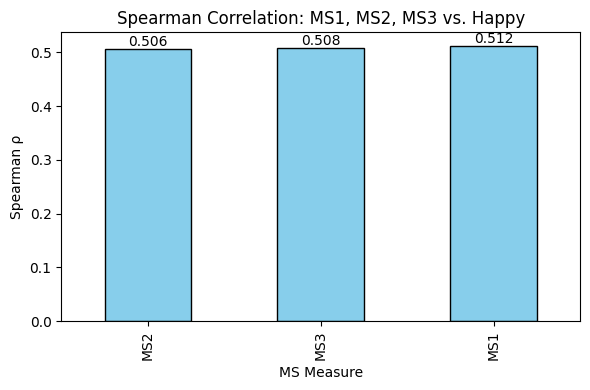

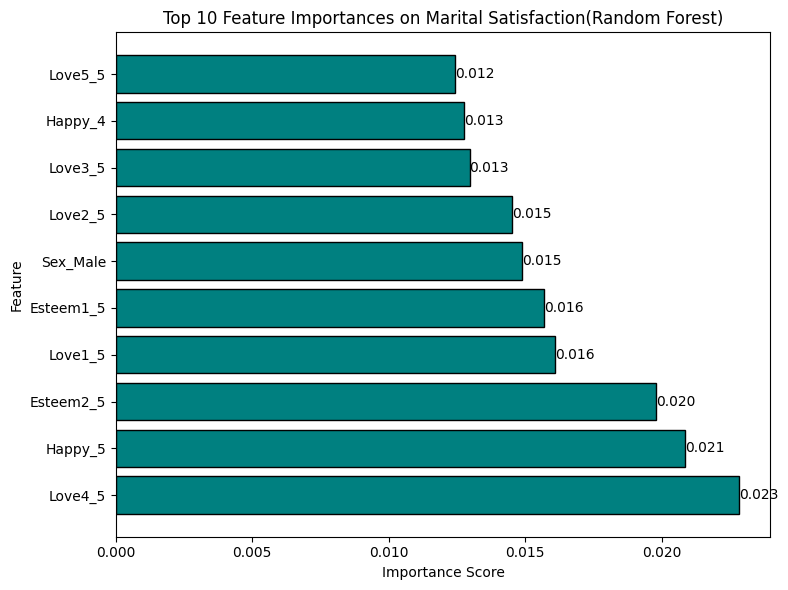

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Visualize Spearman correlations for MS vs. Happy
corr_series = pd.Series(corrs).sort_values()
plt.figure(figsize=(6, 4))
corr_series.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Spearman Correlation: MS1, MS2, MS3 vs. Happy')
plt.ylabel('Spearman ρ')
plt.xlabel('MS Measure')
for idx, val in enumerate(corr_series):
    plt.text(idx, val, f'{val:.3f}', ha='center', va='bottom' if val>=0 else 'top')
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

# 1. Grab your top 10 importances
top10 = importances.head(10)

# 2. Convert the index (feature names) to plain strings
features = top10.index.astype(str)   # now a regular Index of Python str
values   = top10.values               # numeric values

# 3. Plot
plt.figure(figsize=(8, 6))
plt.barh(features, values, color='teal', edgecolor='black')
plt.title('Top 10 Feature Importances on Marital Satisfaction(Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

# 4. Annotate each bar
for i, v in enumerate(values):
    plt.text(v, i, f'{v:.3f}', va='center', ha='left')

plt.tight_layout()
plt.show()



## 3. Model Building

In [ ]:
# Model Building Section - Part 1: Imports and Setup
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours
from imblearn.combine import SMOTETomek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Model Building Section - Part 2: Data Preparation
print("=== DATA PREPARATION ===")

# Use the target variable (best_ms) as classification target
y = df[best_ms].cat.codes  # Convert categorical to numeric codes
X = X_encoded  # Use the encoded features from preprocessing

# Check original class distribution
print("Original class distribution:")
class_dist = pd.Series(y).value_counts().sort_index()
print(class_dist)
print(f"Class balance ratio: {class_dist.min()}/{class_dist.max()} = {class_dist.min()/class_dist.max():.3f}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Feature scaling for algorithms that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

=== DATA PREPARATION ===
Original class distribution:
0     153
1     190
2     291
3     525
4    1077
5    2127
6    2674
Name: count, dtype: int64
Class balance ratio: 153/2674 = 0.057

Training set size: (5629, 126)
Test set size: (1408, 126)


In [ ]:
# Model Building Section - Part 3: Class Imbalance Handling
print("\n=== CLASS IMBALANCE HANDLING TECHNIQUES ===")

# Technique 1: SMOTE Oversampling
print("1. SMOTE Oversampling:")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
print(f"   After SMOTE - Training size: {X_train_smote.shape}")
print(f"   SMOTE class distribution: {pd.Series(y_train_smote).value_counts().sort_index().to_dict()}")

# Technique 2: Random Undersampling
print("\n2. Random Undersampling:")
undersampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_scaled, y_train)
print(f"   After Undersampling - Training size: {X_train_under.shape}")
print(f"   Undersampling class distribution: {pd.Series(y_train_under).value_counts().sort_index().to_dict()}")

# Technique 3: Combined SMOTE + Tomek (Bonus)
print("\n3. Combined SMOTE + Tomek:")
smote_tomek = SMOTETomek(random_state=42)
X_train_combined, y_train_combined = smote_tomek.fit_resample(X_train_scaled, y_train)
print(f"   After SMOTE+Tomek - Training size: {X_train_combined.shape}")
print(f"   Combined class distribution: {pd.Series(y_train_combined).value_counts().sort_index().to_dict()}")

# Store sampling strategies for evaluation
sampling_strategies = {
    'Original': (X_train_scaled, y_train),
    'SMOTE': (X_train_smote, y_train_smote),
    'Undersampling': (X_train_under, y_train_under),
    'SMOTE+Tomek': (X_train_combined, y_train_combined)
}


=== CLASS IMBALANCE HANDLING TECHNIQUES ===
1. SMOTE Oversampling:
   After SMOTE - Training size: (14973, 126)
   SMOTE class distribution: {0: 2139, 1: 2139, 2: 2139, 3: 2139, 4: 2139, 5: 2139, 6: 2139}

2. Random Undersampling:
   After Undersampling - Training size: (854, 126)
   Undersampling class distribution: {0: 122, 1: 122, 2: 122, 3: 122, 4: 122, 5: 122, 6: 122}

3. Combined SMOTE + Tomek:
   After SMOTE+Tomek - Training size: (14833, 126)
   Combined class distribution: {0: 2139, 1: 2139, 2: 2139, 3: 2139, 4: 2135, 5: 2070, 6: 2072}


In [ ]:
# Model Building Section - Part 4: Model Definitions (5 Fastest Models)
print("\n=== MODEL DEFINITIONS ===")

# Import LDA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Define 5 fastest classification models (replaced Random Forest with LDA)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Linear Discriminant Analysis': LinearDiscriminantAnalysis()
}

# hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'C': [1, 10],
        'solver': ['lbfgs'],
        'penalty': ['l2']
    },
    'Decision Tree': {
        'max_depth': [10, None],
        'min_samples_split': [2, 5],
        'criterion': ['gini']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8]
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5],
        'weights': ['uniform', 'distance']
    },
    'Linear Discriminant Analysis': {
        'solver': ['svd', 'lsqr'],
        'shrinkage': [None, 'auto']
    }
}

print(f"Total models defined: {len(models)}")
for model_name in models.keys():
    print(f"- {model_name}")


=== MODEL DEFINITIONS ===
Total models defined: 5
- Logistic Regression
- Decision Tree
- Naive Bayes
- K-Nearest Neighbors
- Linear Discriminant Analysis


In [ ]:
# Model Building Section - Part 5A: Setup and Original Data Training
print("\n=== MODEL TRAINING ===")

# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
all_results = []
best_models = {}

# Train with Original Data first
strategy_name = 'Original'
X_train_strategy, y_train_strategy = sampling_strategies[strategy_name]
print(f"\n--- Training with {strategy_name} Data ---")

for model_name, model in models.items():
    print(f"Training {model_name}...")

    try:
        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            cv=3,  # Reduced for speed
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=0
        )

        # Fit the grid search
        grid_search.fit(X_train_strategy, y_train_strategy)

        # Get best model
        best_model = grid_search.best_estimator_

        # Cross-validation scores
        cv_scores = cross_val_score(
            best_model, X_train_strategy, y_train_strategy,
            cv=cv, scoring='f1_weighted'
        )

        # Predictions on test set
        y_pred = best_model.predict(X_test_scaled)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # Store results
        result = {
            'Strategy': strategy_name,
            'Model': model_name,
            'Best_Params': grid_search.best_params_,
            'CV_Score_Mean': cv_scores.mean(),
            'CV_Score_Std': cv_scores.std(),
            'Test_Accuracy': accuracy,
            'Test_Precision': precision,
            'Test_Recall': recall,
            'Test_F1': f1
        }

        all_results.append(result)

        # Store best model
        key = f"{strategy_name}_{model_name}"
        best_models[key] = best_model

        print(f"   CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        print(f"   Test F1: {f1:.3f}")

    except Exception as e:
        print(f"   Error training {model_name}: {str(e)}")
        continue

print(f"\nCompleted {strategy_name} strategy. Models trained so far: {len(all_results)}")


=== MODEL TRAINING ===

--- Training with Original Data ---
Training Logistic Regression...
   CV F1: 0.479 ± 0.007
   Test F1: 0.498
Training Decision Tree...
   CV F1: 0.461 ± 0.009
   Test F1: 0.452
Training Naive Bayes...
   CV F1: 0.407 ± 0.023
   Test F1: 0.436
Training K-Nearest Neighbors...
   CV F1: 0.422 ± 0.012
   Test F1: 0.426
Training Linear Discriminant Analysis...
   CV F1: 0.485 ± 0.014
   Test F1: 0.496

Completed Original strategy. Models trained so far: 5


In [ ]:
# Model Building Section - Part 5B: SMOTE Strategy Training
print("\n=== MODEL TRAINING ===")

# Train with SMOTE Data
strategy_name = 'SMOTE'
X_train_strategy, y_train_strategy = sampling_strategies[strategy_name]
print(f"\n--- Training with {strategy_name} Data ---")

for model_name, model in models.items():
    print(f"Training {model_name}...")

    try:
        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            cv=3,  # Reduced for speed
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=0
        )

        # Fit the grid search
        grid_search.fit(X_train_strategy, y_train_strategy)

        # Get best model
        best_model = grid_search.best_estimator_

        # Cross-validation scores
        cv_scores = cross_val_score(
            best_model, X_train_strategy, y_train_strategy,
            cv=cv, scoring='f1_weighted'
        )

        # Predictions on test set
        y_pred = best_model.predict(X_test_scaled)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # Store results
        result = {
            'Strategy': strategy_name,
            'Model': model_name,
            'Best_Params': grid_search.best_params_,
            'CV_Score_Mean': cv_scores.mean(),
            'CV_Score_Std': cv_scores.std(),
            'Test_Accuracy': accuracy,
            'Test_Precision': precision,
            'Test_Recall': recall,
            'Test_F1': f1
        }

        all_results.append(result)

        # Store best model
        key = f"{strategy_name}_{model_name}"
        best_models[key] = best_model

        print(f"   CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        print(f"   Test F1: {f1:.3f}")

    except Exception as e:
        print(f"   Error training {model_name}: {str(e)}")
        continue

print(f"\nCompleted {strategy_name} strategy. Models trained so far: {len(all_results)}")


=== MODEL TRAINING ===

--- Training with SMOTE Data ---
Training Logistic Regression...
   CV F1: 0.508 ± 0.004
   Test F1: 0.435
Training Decision Tree...
   CV F1: 0.708 ± 0.004
   Test F1: 0.390
Training Naive Bayes...
   CV F1: 0.325 ± 0.017
   Test F1: 0.439
Training K-Nearest Neighbors...
   CV F1: 0.812 ± 0.003
   Test F1: 0.355
Training Linear Discriminant Analysis...
   CV F1: 0.476 ± 0.008
   Test F1: 0.462

Completed SMOTE strategy. Models trained so far: 10


In [ ]:
# Model Building Section - Part 5C: Undersampling Strategy Training
print("\n=== MODEL TRAINING ===")

# Train with Undersampling Data
strategy_name = 'Undersampling'
X_train_strategy, y_train_strategy = sampling_strategies[strategy_name]
print(f"\n--- Training with {strategy_name} Data ---")

for model_name, model in models.items():
    print(f"Training {model_name}...")

    try:
        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            cv=3,  # Reduced for speed
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=0
        )

        # Fit the grid search
        grid_search.fit(X_train_strategy, y_train_strategy)

        # Get best model
        best_model = grid_search.best_estimator_

        # Cross-validation scores
        cv_scores = cross_val_score(
            best_model, X_train_strategy, y_train_strategy,
            cv=cv, scoring='f1_weighted'
        )

        # Predictions on test set
        y_pred = best_model.predict(X_test_scaled)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # Store results
        result = {
            'Strategy': strategy_name,
            'Model': model_name,
            'Best_Params': grid_search.best_params_,
            'CV_Score_Mean': cv_scores.mean(),
            'CV_Score_Std': cv_scores.std(),
            'Test_Accuracy': accuracy,
            'Test_Precision': precision,
            'Test_Recall': recall,
            'Test_F1': f1
        }

        all_results.append(result)

        # Store best model
        key = f"{strategy_name}_{model_name}"
        best_models[key] = best_model

        print(f"   CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        print(f"   Test F1: {f1:.3f}")

    except Exception as e:
        print(f"   Error training {model_name}: {str(e)}")
        continue

print(f"\nCompleted {strategy_name} strategy. Models trained so far: {len(all_results)}")


=== MODEL TRAINING ===

--- Training with Undersampling Data ---
Training Logistic Regression...
   CV F1: 0.274 ± 0.034
   Test F1: 0.380
Training Decision Tree...
   CV F1: 0.260 ± 0.048
   Test F1: 0.339
Training Naive Bayes...
   CV F1: 0.232 ± 0.019
   Test F1: 0.385
Training K-Nearest Neighbors...
   CV F1: 0.225 ± 0.023
   Test F1: 0.367
Training Linear Discriminant Analysis...
   CV F1: 0.319 ± 0.021
   Test F1: 0.450

Completed Undersampling strategy. Models trained so far: 15


In [ ]:
# Model Building Section - Part 5D: Combined Strategy Training
print("\n=== MODEL TRAINING ===")

# Train with SMOTE+Tomek Data
strategy_name = 'SMOTE+Tomek'
X_train_strategy, y_train_strategy = sampling_strategies[strategy_name]
print(f"\n--- Training with {strategy_name} Data ---")

for model_name, model in models.items():
    print(f"Training {model_name}...")

    try:
        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(
            model,
            param_grids[model_name],
            cv=3,  # Reduced for speed
            scoring='f1_weighted',
            n_jobs=-1,
            verbose=0
        )

        # Fit the grid search
        grid_search.fit(X_train_strategy, y_train_strategy)

        # Get best model
        best_model = grid_search.best_estimator_

        # Cross-validation scores
        cv_scores = cross_val_score(
            best_model, X_train_strategy, y_train_strategy,
            cv=cv, scoring='f1_weighted'
        )

        # Predictions on test set
        y_pred = best_model.predict(X_test_scaled)

        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

        # Store results
        result = {
            'Strategy': strategy_name,
            'Model': model_name,
            'Best_Params': grid_search.best_params_,
            'CV_Score_Mean': cv_scores.mean(),
            'CV_Score_Std': cv_scores.std(),
            'Test_Accuracy': accuracy,
            'Test_Precision': precision,
            'Test_Recall': recall,
            'Test_F1': f1
        }

        all_results.append(result)

        # Store best model
        key = f"{strategy_name}_{model_name}"
        best_models[key] = best_model

        print(f"   CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        print(f"   Test F1: {f1:.3f}")

    except Exception as e:
        print(f"   Error training {model_name}: {str(e)}")
        continue

print(f"\nCompleted {strategy_name} strategy. Total models trained: {len(all_results)}")


=== MODEL TRAINING ===

--- Training with SMOTE+Tomek Data ---
Training Logistic Regression...
   CV F1: 0.505 ± 0.010
   Test F1: 0.425
Training Decision Tree...
   CV F1: 0.683 ± 0.003
   Test F1: 0.409
Training Naive Bayes...
   CV F1: 0.333 ± 0.006
   Test F1: 0.418
Training K-Nearest Neighbors...
   CV F1: 0.820 ± 0.007
   Test F1: 0.368
Training Linear Discriminant Analysis...
   CV F1: 0.481 ± 0.011
   Test F1: 0.460

Completed SMOTE+Tomek strategy. Total models trained: 20


In [ ]:
# Model Building Section - Part 5E: Quick Results Summary
print("\n=== TRAINING COMPLETED - QUICK SUMMARY ===")

# Convert results to DataFrame for quick preview
results_df = pd.DataFrame(all_results)

# Show current best performers
if len(all_results) > 0:
    print(f"Total models trained: {len(all_results)}")
    print("\nTop 5 models so far:")
    top_5 = results_df.nlargest(5, 'Test_F1')[['Strategy', 'Model', 'Test_F1', 'Test_Accuracy']]
    print(top_5.to_string(index=False))

    # Best model so far
    best_so_far = results_df.loc[results_df['Test_F1'].idxmax()]
    print(f"\nCurrent best model: {best_so_far['Model']} ({best_so_far['Strategy']}) - F1: {best_so_far['Test_F1']:.4f}")
else:
    print("No models completed yet.")

print("\n=== Ready for results analysis and visualization ===")


=== TRAINING COMPLETED - QUICK SUMMARY ===
Total models trained: 20

Top 5 models so far:
   Strategy                        Model  Test_F1  Test_Accuracy
   Original          Logistic Regression 0.497514       0.519176
   Original Linear Discriminant Analysis 0.496203       0.513494
      SMOTE Linear Discriminant Analysis 0.461893       0.454545
SMOTE+Tomek Linear Discriminant Analysis 0.460198       0.451705
   Original                Decision Tree 0.452124       0.470881

Current best model: Logistic Regression (Original) - F1: 0.4975

=== Ready for results analysis and visualization ===



=== RESULTS ANALYSIS ===
Top 10 Models by Test F1 Score:
     Strategy                        Model  Test_F1  Test_Accuracy  CV_Score_Mean
     Original          Logistic Regression 0.497514       0.519176       0.478788
     Original Linear Discriminant Analysis 0.496203       0.513494       0.485477
        SMOTE Linear Discriminant Analysis 0.461893       0.454545       0.475866
  SMOTE+Tomek Linear Discriminant Analysis 0.460198       0.451705       0.481187
     Original                Decision Tree 0.452124       0.470881       0.461428
Undersampling Linear Discriminant Analysis 0.450490       0.448153       0.319348
        SMOTE                  Naive Bayes 0.438949       0.433949       0.324822
     Original                  Naive Bayes 0.436141       0.448153       0.407311
        SMOTE          Logistic Regression 0.434772       0.416903       0.508392
     Original          K-Nearest Neighbors 0.426253       0.450994       0.422492

Best Overall Model:
Strategy: Original


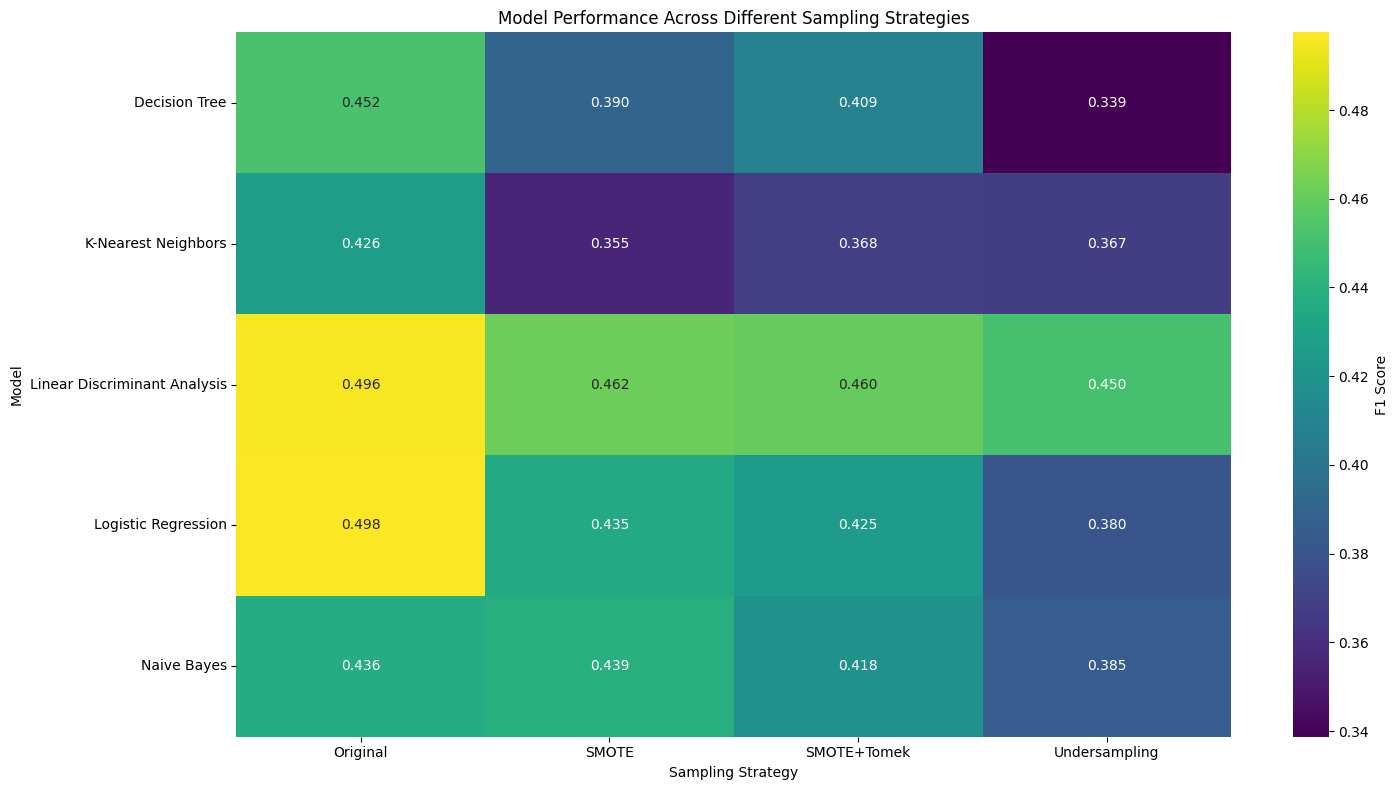

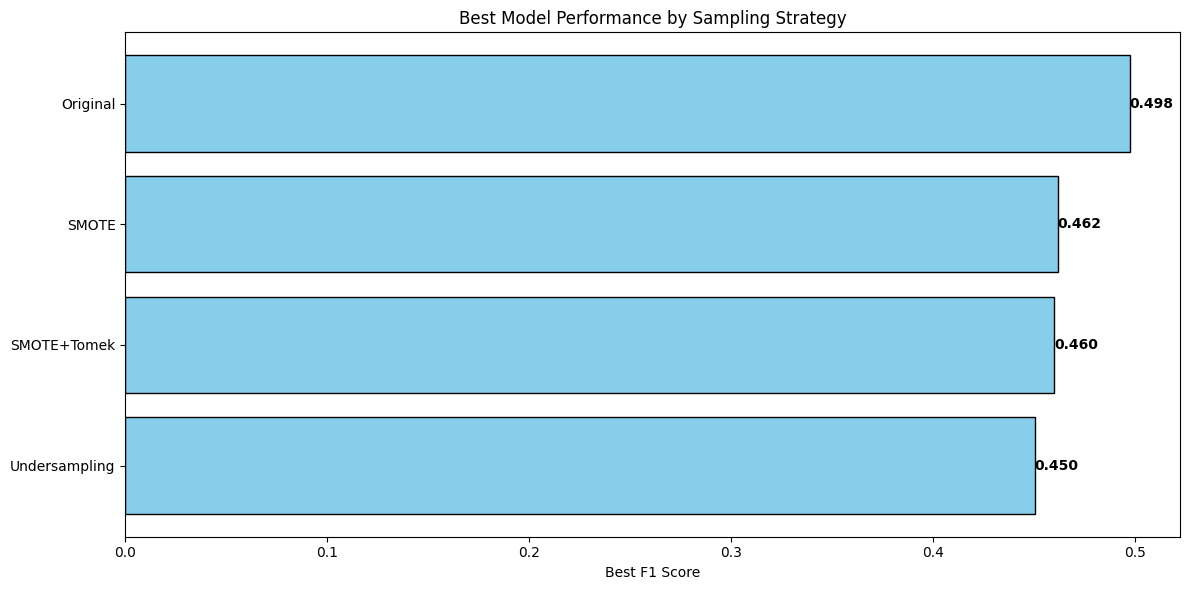

In [ ]:
# Model Building Section - Part 6: Results Analysis
print("\n=== RESULTS ANALYSIS ===")

# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Display top performing models
print("Top 10 Models by Test F1 Score:")
top_models = results_df.nlargest(10, 'Test_F1')[['Strategy', 'Model', 'Test_F1', 'Test_Accuracy', 'CV_Score_Mean']]
print(top_models.to_string(index=False))

# Best model overall
best_overall = results_df.loc[results_df['Test_F1'].idxmax()]
print(f"\nBest Overall Model:")
print(f"Strategy: {best_overall['Strategy']}")
print(f"Model: {best_overall['Model']}")
print(f"Test F1: {best_overall['Test_F1']:.4f}")
print(f"Best Parameters: {best_overall['Best_Params']}")

# Visualization 1: Model Performance Comparison
plt.figure(figsize=(15, 8))
pivot_data = results_df.pivot(index='Model', columns='Strategy', values='Test_F1')
sns.heatmap(pivot_data, annot=True, cmap='viridis', fmt='.3f', cbar_kws={'label': 'F1 Score'})
plt.title('Model Performance Across Different Sampling Strategies')
plt.xlabel('Sampling Strategy')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# Visualization 2: Best Models by Strategy
plt.figure(figsize=(12, 6))
strategy_best = results_df.groupby('Strategy')['Test_F1'].max().sort_values(ascending=True)
bars = plt.barh(strategy_best.index, strategy_best.values, color='skyblue', edgecolor='black')
plt.xlabel('Best F1 Score')
plt.title('Best Model Performance by Sampling Strategy')
for bar, value in zip(bars, strategy_best.values):
    plt.text(value, bar.get_y() + bar.get_height()/2, f'{value:.3f}',
             ha='left', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


=== FINAL MODEL EVALUATION ===
Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.47      0.23      0.30        31
           1       0.43      0.16      0.23        38
           2       0.31      0.22      0.26        58
           3       0.40      0.29      0.33       105
           4       0.40      0.28      0.33       215
           5       0.46      0.45      0.45       426
           6       0.61      0.79      0.69       535

    accuracy                           0.52      1408
   macro avg       0.44      0.34      0.37      1408
weighted avg       0.50      0.52      0.50      1408



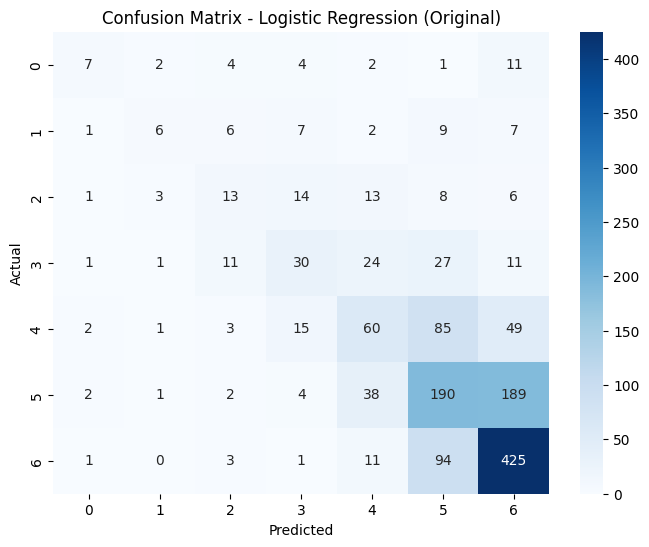


=== MODEL BUILDING COMPLETED ===
Best Model: Logistic Regression with Original sampling
Final Test F1 Score: 0.4975


In [ ]:
# Model Building Section - Part 7: Final Evaluation
print("\n=== FINAL MODEL EVALUATION ===")

# Get the best model
best_key = f"{best_overall['Strategy']}_{best_overall['Model']}"
final_model = best_models[best_key]

# Make predictions
y_pred_final = final_model.predict(X_test_scaled)

# Detailed classification report
print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_overall["Model"]} ({best_overall["Strategy"]})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance (if available)
if hasattr(final_model, 'feature_importances_'):
    feature_importance = pd.Series(final_model.feature_importances_, index=X.columns)
    top_10_features = feature_importance.nlargest(10)

    plt.figure(figsize=(10, 6))
    top_10_features.plot(kind='barh', color='teal', edgecolor='black')
    plt.title('Top 10 Feature Importances (Final Model)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

print("\n=== MODEL BUILDING COMPLETED ===")
print(f"Best Model: {best_overall['Model']} with {best_overall['Strategy']} sampling")
print(f"Final Test F1 Score: {best_overall['Test_F1']:.4f}")

## 4. Knowledge Evaluation

    Feature_Group  Accuracy  F1_weighted
0    all_features  0.521591     0.494831
1  top10_features  0.484659     0.439797
2   top3_features  0.460795     0.393679


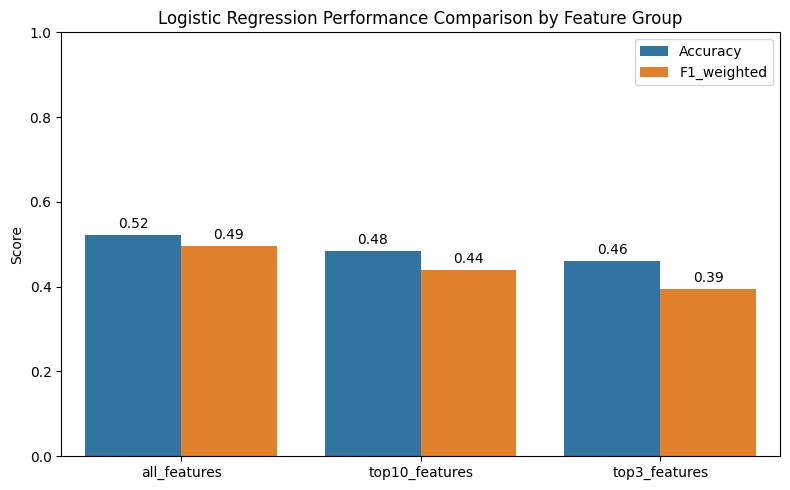

In [ ]:

# 1. Feature Group Comparison on Logistic Regression ===
feature_groups = {
    'all_features':  all_features,
    'top10_features': top10_features,
    'top3_features':  top3_features
}

# === 2) Imports & scaling ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing      import StandardScaler
from sklearn.model_selection     import train_test_split
from sklearn.metrics             import accuracy_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


scaler  = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded),
                        columns=X_encoded.columns)

# === 3) Single stratified split ===
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, random_state=42
)

# === 4) Fit & evaluate Logistic Regression on each group ===
results = []
is_binary = len(np.unique(y)) == 2

for name, feats in feature_groups.items():
    X_train = X_train_base[feats]
    X_test  = X_test_base[feats]

    model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for potential small datasets
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    row = {
        'Feature_Group': name,
        'Accuracy':      acc,
        'F1_weighted':   f1
    }

    if is_binary:
        y_prob      = model.predict_proba(X_test)[:, 1]
        row['ROC_AUC'] = roc_auc_score(y_test, y_prob)

    results.append(row)

# === 5) Show results ===
results_df = pd.DataFrame(results)
print(results_df)

# === 6) Prepare data for plotting (melt results_df) ===
plot_df = results_df.melt(
    id_vars='Feature_Group',
    var_name='Metric',
    value_name='Score'
)

# === 7) Add labels on each bar ===
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=plot_df, x='Feature_Group', y='Score', hue='Metric')
plt.ylim(0, 1)
plt.title('Logistic Regression Performance Comparison by Feature Group')
plt.xlabel('')
plt.ylabel('Score')

# Annotate each bar with its height
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.legend(title='')
plt.tight_layout()
plt.show()

In [ ]:
# 2. Scaling Comparison on Top-10 Features (Logistic Regression) ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1) Prepare Top-10 feature matrix
X_top10 = X_encoded[top10_features]
scaler = StandardScaler()
X_top10_scaled = pd.DataFrame(
    scaler.fit_transform(X_top10),
    columns=top10_features,
    index=X_top10.index
)

# 2) Define three target granularities
#   – Original 7-level codes (0 through 6)
y7 = df[best_ms].cat.codes

#   – 5-level: merge extreme categories into the two ends
#     [0,1]→0, 2→1, 3→2, 4→3, [5,6]→4
y5 = pd.cut(
    y7,
    bins=[-0.1, 1.5, 2.5, 3.5, 4.5, 6.1],
    labels=False
)

#   – Binary: low (0–3) vs. high (4–6)
y2 = (y7 >= 4).astype(int)

targets = {
    '7-level': y7,
    '5-level': y5,
    'binary': y2
}

# 3) Evaluate Logistic Regression under each granularity
results_scale = []
for name, y in targets.items():
    # stratified split for THIS target
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_top10_scaled, y,
        test_size=0.2, random_state=42, stratify=y
    )
    model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for potential small datasets
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    if name == 'binary':
        f1 = f1_score(y_te, y_pred)  # default is binary
        roc = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])
    else:
        f1 = f1_score(y_te, y_pred, average='weighted', zero_division=0)
        roc = None

    row = {'Granularity': name, 'Accuracy': acc, 'F1_weighted': f1}
    if roc is not None:
        row['ROC_AUC'] = roc
    results_scale.append(row)

# 4) Show your comparison
results_scale_df = pd.DataFrame(results_scale)
print(results_scale_df)

  Granularity  Accuracy  F1_weighted   ROC_AUC
0     7-level  0.485085     0.440033       NaN
1     5-level  0.701705     0.646960       NaN
2      binary  0.857244     0.918853  0.844201



=== Top 10 Global Features (Binary Satisfaction, All Features - Logistic Regression) ===
       Feature  Logistic_Regression_Coefficient
0    Esteem1_5                         0.837437
1    Esteem2_5                         0.823827
2    Esteem1_4                         0.809001
3      Love1_5                         0.757855
4    Esteem2_4                         0.552224
5      Love1_4                         0.490810
6      Love4_5                         0.476478
7      Love4_4                         0.406657
8  ChildAP-S_6                        -0.394339
9  ChildAP-S_7                        -0.378203


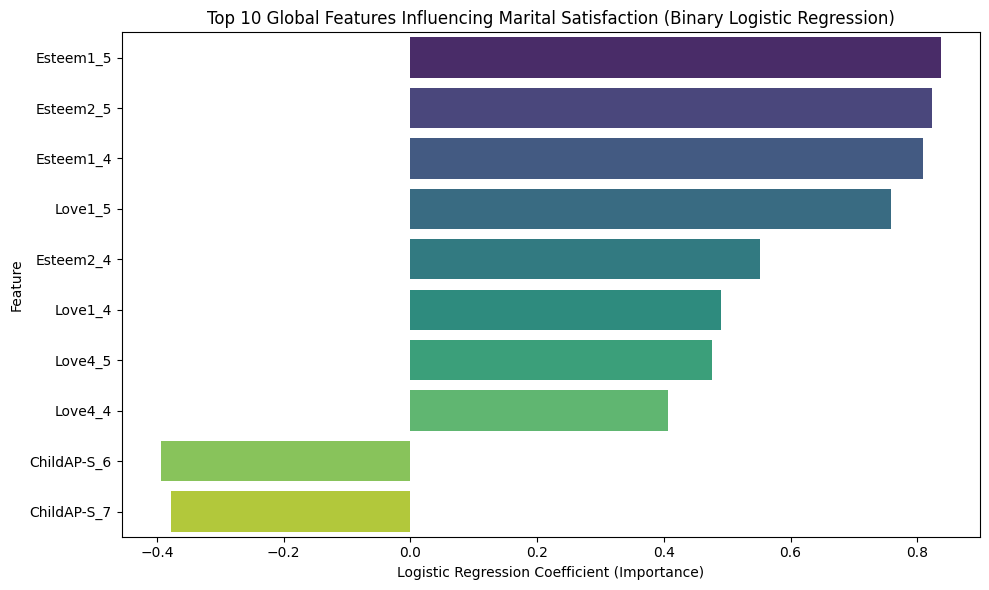

In [ ]:
#  3. Global Top Features (Best Scaling) (Logistic Regression) ===
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Use binary target (best from Step 2 based on F1 & AUC)
y_bin = (df[best_ms].cat.codes >= 4).astype(int)

# 2. Use all features
X_all = X_encoded[all_features]

# 3. Standard scale
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_all),
                        columns=all_features, index=X_all.index)

# 4. Fit Logistic Regression
model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for potential small datasets
model.fit(X_scaled, y_bin)

# 5. Extract and rank coefficients
coef = model.coef_[0]  # shape: (n_features,)
top_idx = np.argsort(np.abs(coef))[::-1][:10]

top_features = [(all_features[i], coef[i]) for i in top_idx]
top_df = pd.DataFrame(top_features, columns=['Feature', 'Logistic_Regression_Coefficient'])

print("\n=== Top 10 Global Features (Binary Satisfaction, All Features - Logistic Regression) ===")
print(top_df)


# === 11) Visualize Top 10 Global Features ===
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=top_df, y='Feature', x='Logistic_Regression_Coefficient', palette='viridis')

plt.title('Top 10 Global Features Influencing Marital Satisfaction (Binary Logistic Regression)')
plt.xlabel('Logistic Regression Coefficient (Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


=== Top 10 Global Features for Happiness (Binary Logistic Regression) ===
       Feature  Logistic_Regression_Coefficient
0      Love1_5                         0.789991
1      Love4_5                         0.566050
2    Esteem1_5                         0.525792
3     Physio_4                         0.503808
4      Love2_5                         0.461043
5      Love4_4                         0.400530
6      Love1_4                         0.393626
7     Physio_3                         0.376261
8     Physio_5                         0.369885
9  Education_5                         0.357708


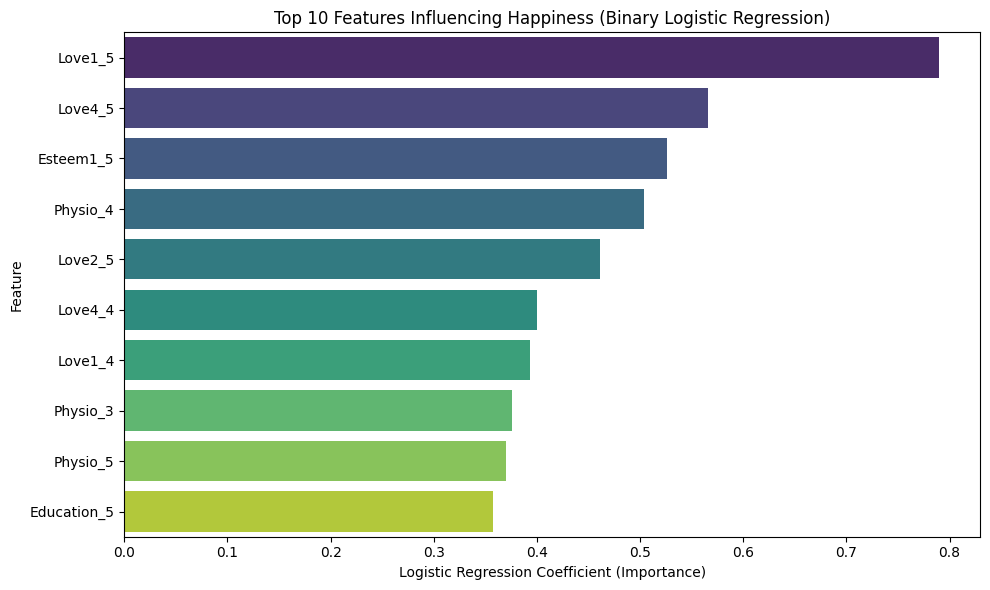

In [ ]:
# Global Top Features for Happiness (Binary) – Updated to drop any ‘Happy’ inputs ===
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Binary‐encode happiness: codes ≥3 → “high”
y_happy = (df['Happy'].cat.codes >= 3).astype(int)

# 2) Prepare feature list by removing any columns related to Happy
features_for_happy = [f for f in all_features if not f.startswith('Happy')]

# 3) Feature matrix: drop any one‐hot dummies for Happy
X_all = X_encoded[features_for_happy]

# 4) Standard‐scale them
scaler = StandardScaler()
X_all_scaled = pd.DataFrame(
    scaler.fit_transform(X_all),
    columns=features_for_happy,
    index=X_all.index
)

# 5) Fit Logistic Regression
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_all_scaled, y_happy)

# 6) Extract top 10 by absolute coefficient
coefs = model.coef_[0]  # Logistic Regression has shape (1, n_features) for binary
top_idx = np.argsort(np.abs(coefs))[::-1][:10]
top_happy_features = [(features_for_happy[i], coefs[i]) for i in top_idx]
top_happy_df = pd.DataFrame(top_happy_features, columns=['Feature','Logistic_Regression_Coefficient'])

print("\n=== Top 10 Global Features for Happiness (Binary Logistic Regression) ===")
print(top_happy_df)

# 7) Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=top_happy_df, y='Feature', x='Logistic_Regression_Coefficient', palette='viridis')
plt.title('Top 10 Features Influencing Happiness (Binary Logistic Regression)')
plt.xlabel('Logistic Regression Coefficient (Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

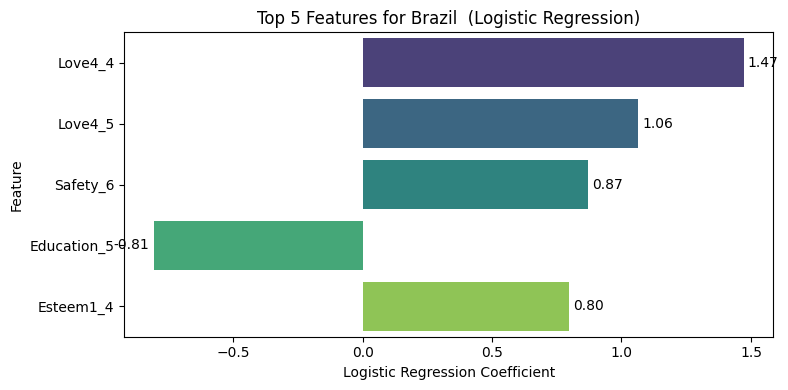

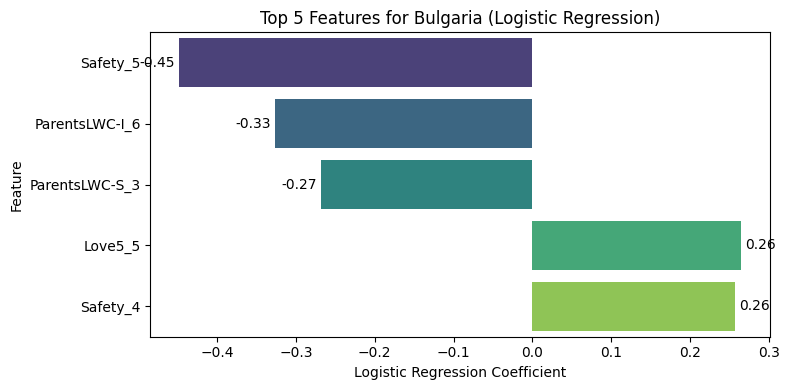

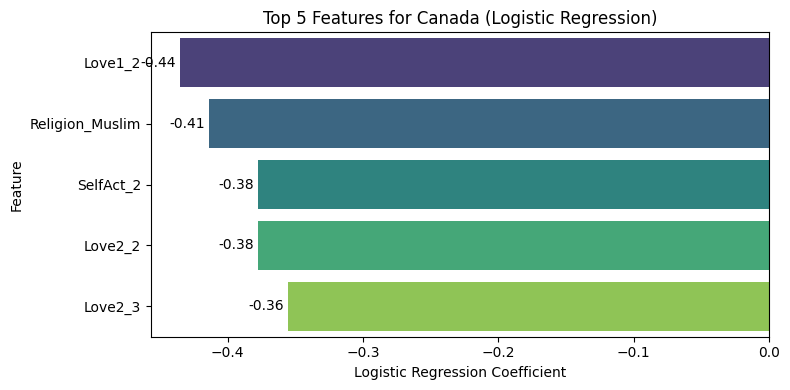

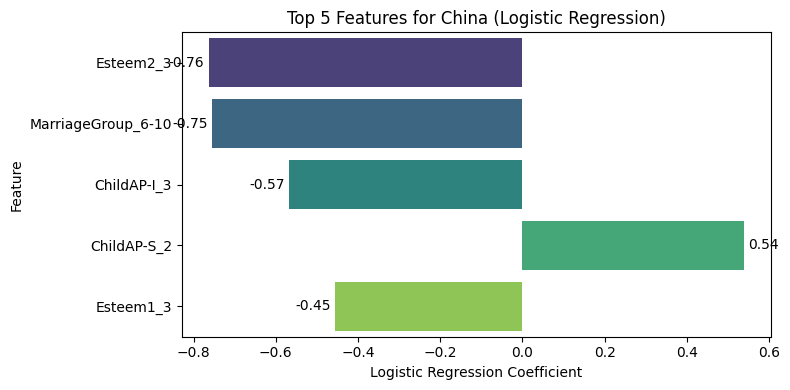

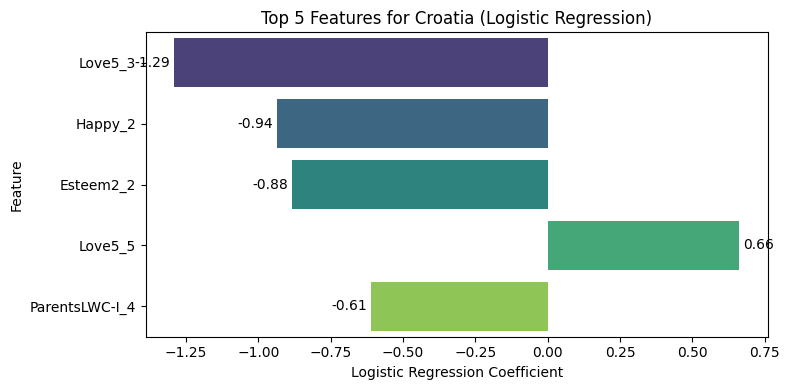

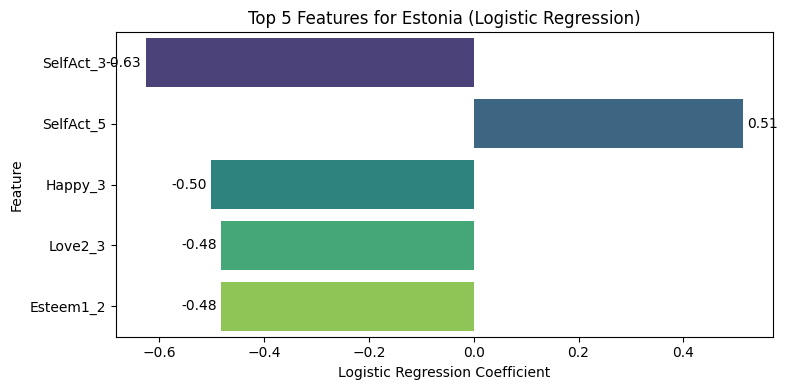

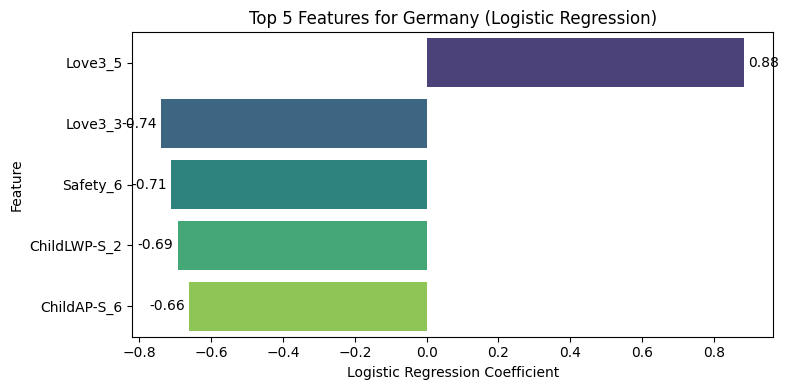

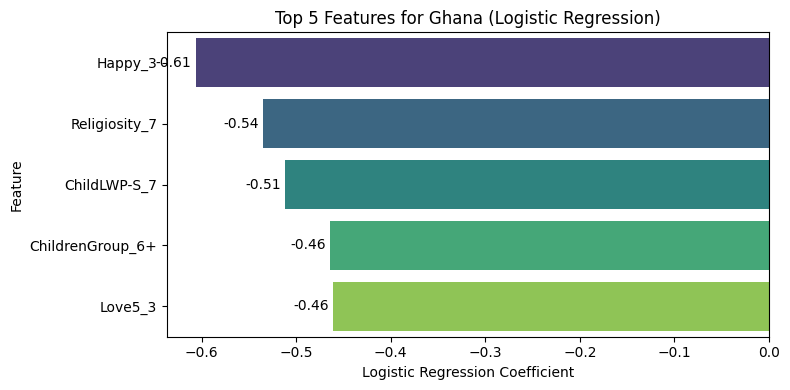

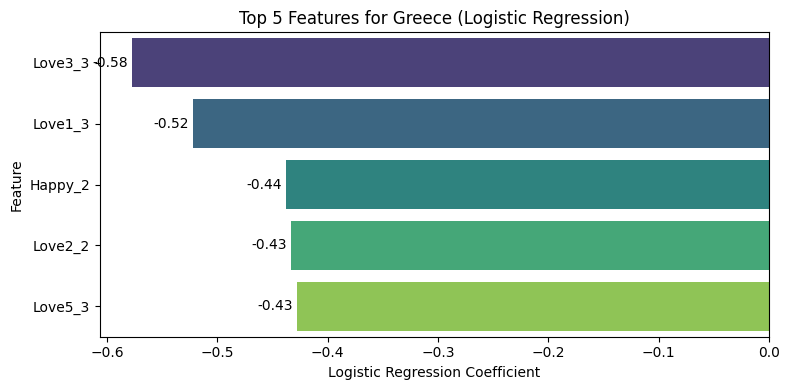

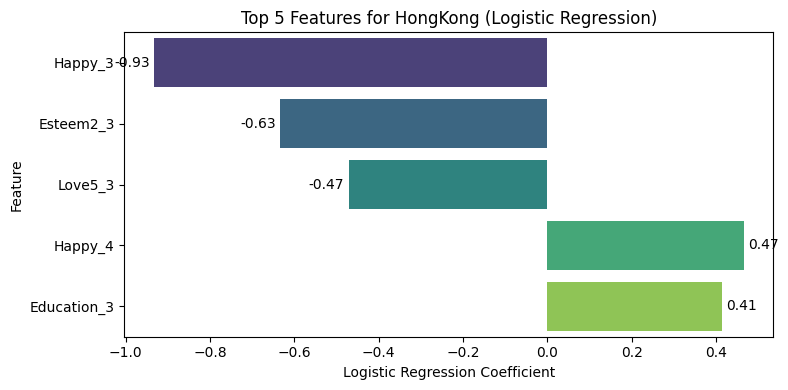

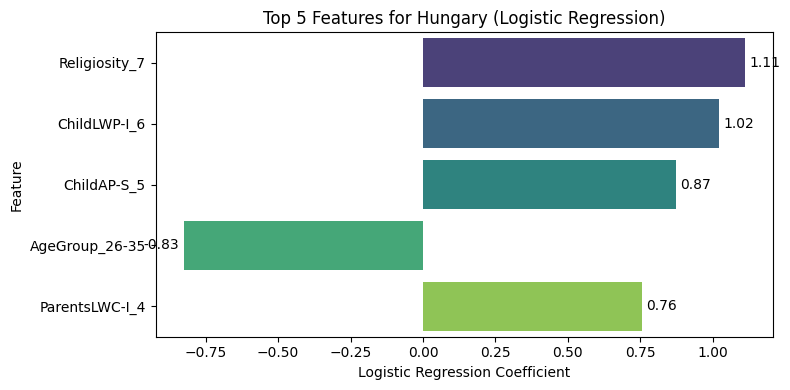

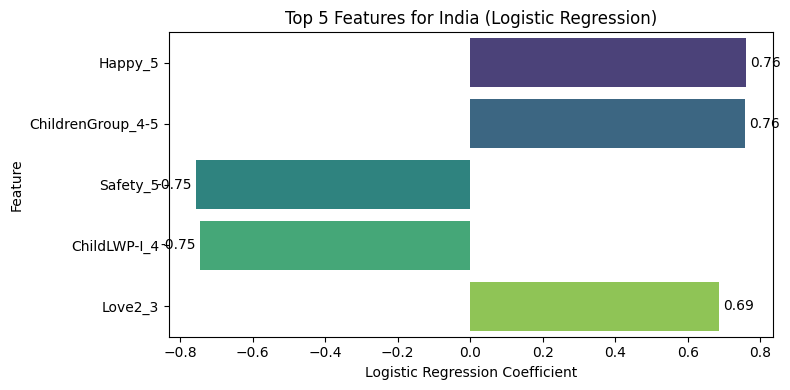

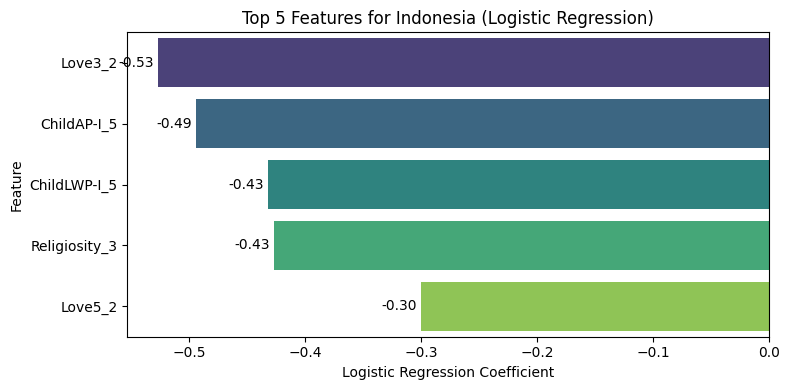

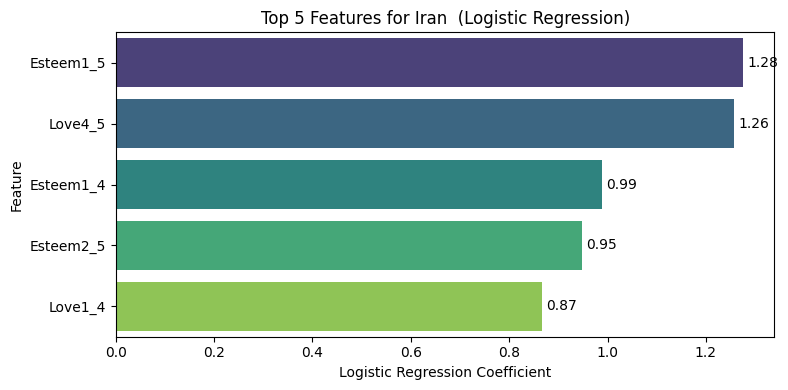

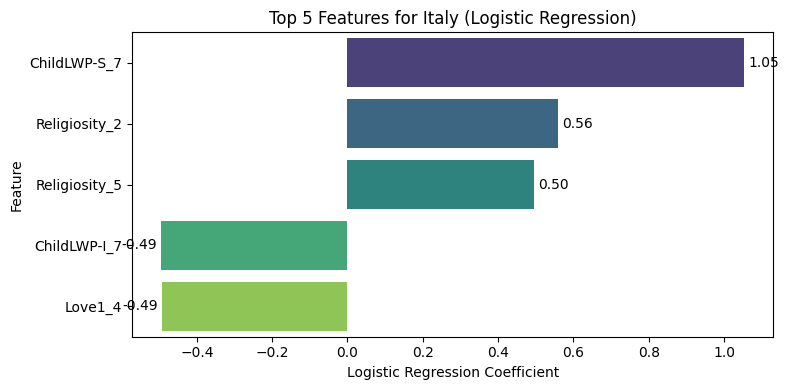

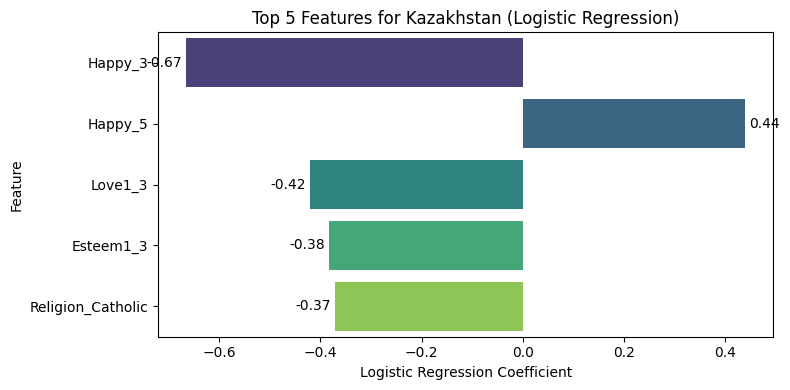

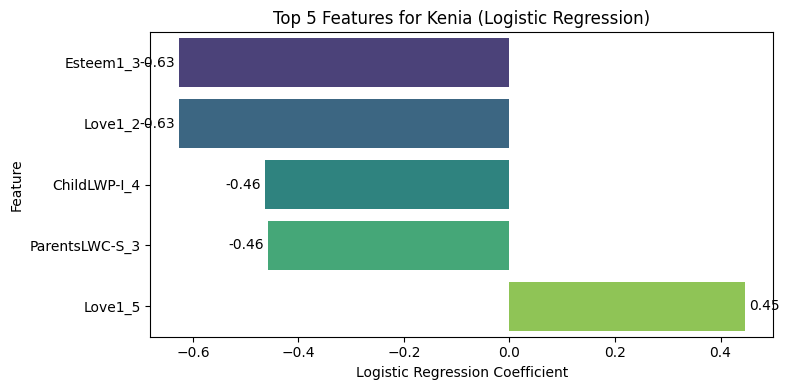

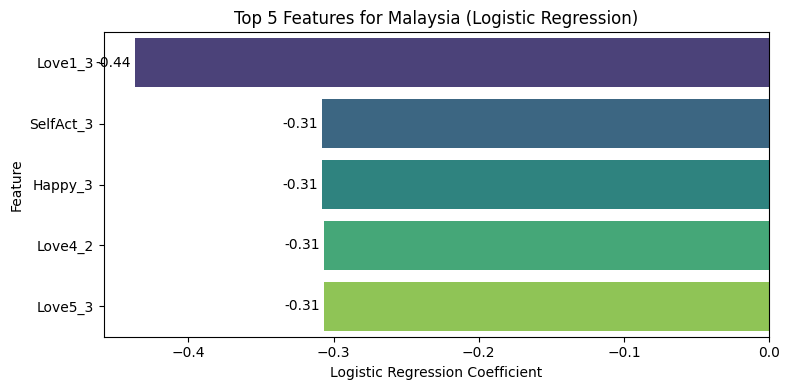

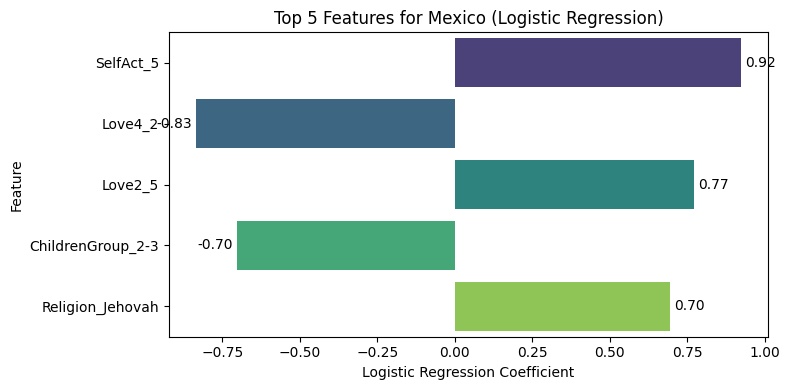

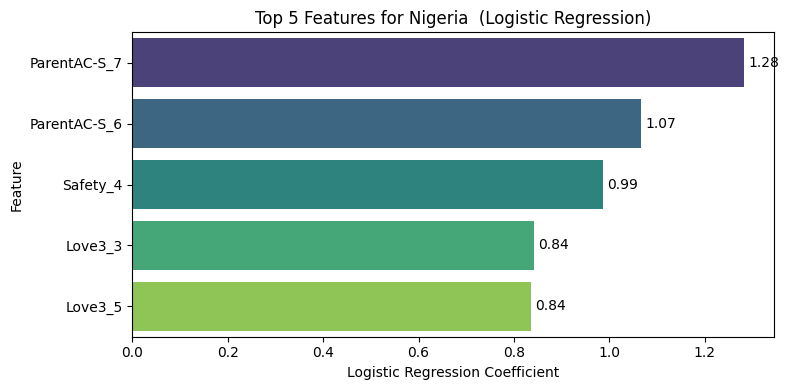

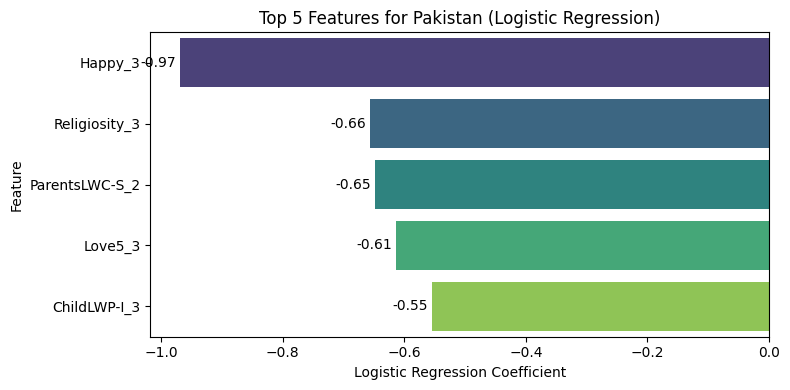

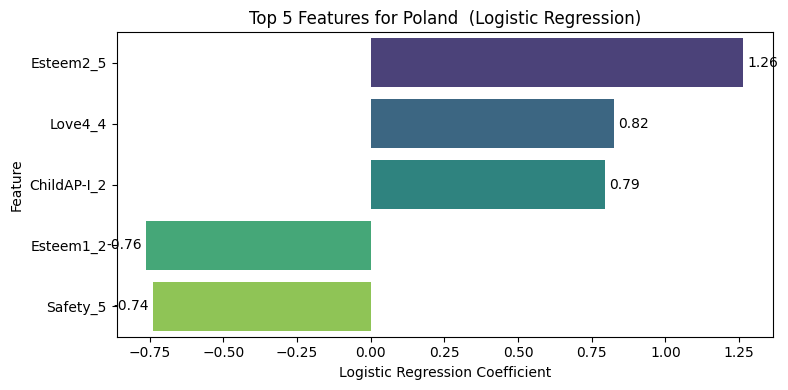

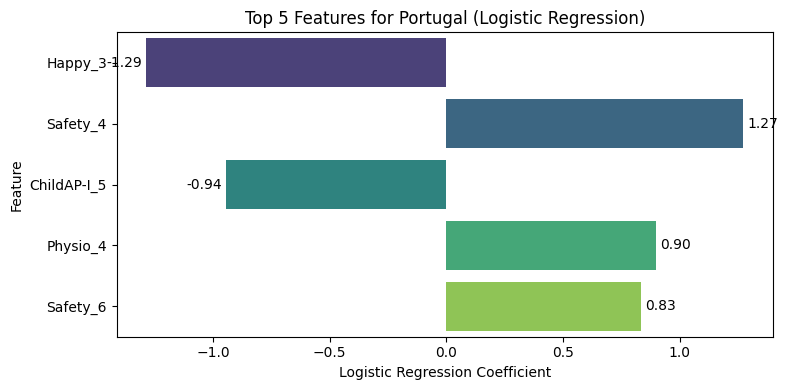

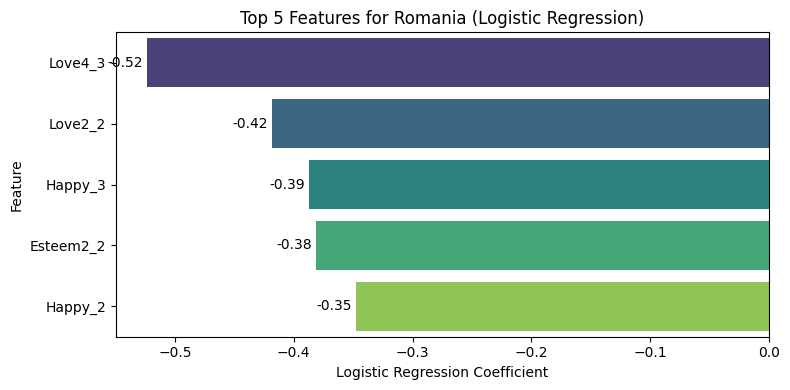

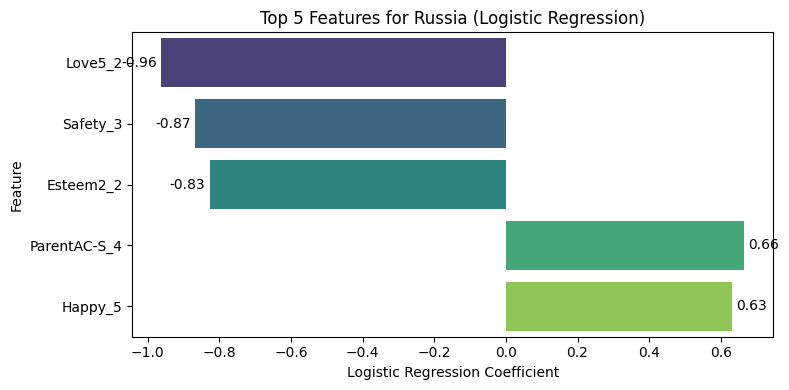

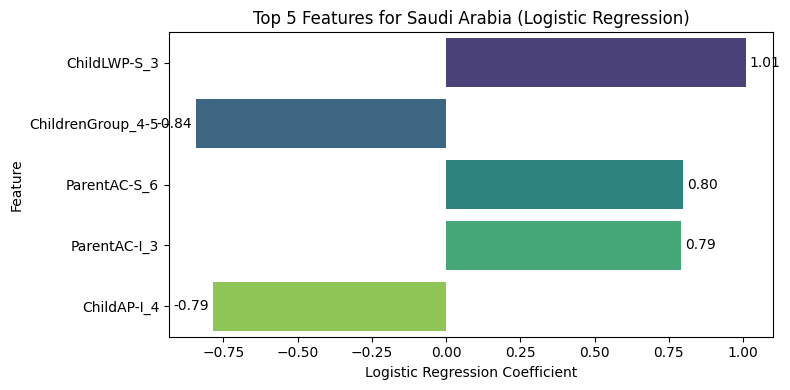

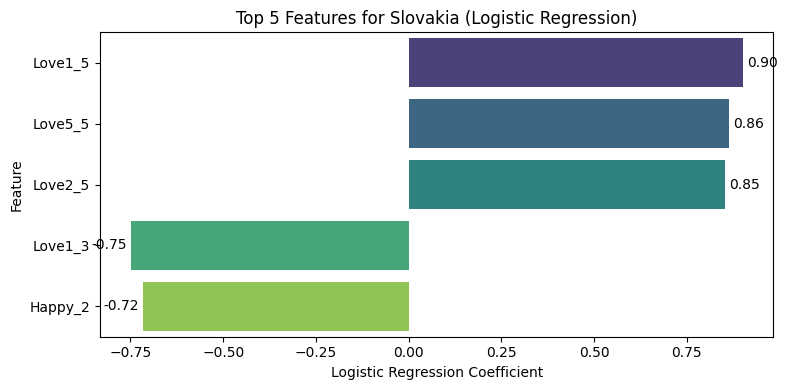

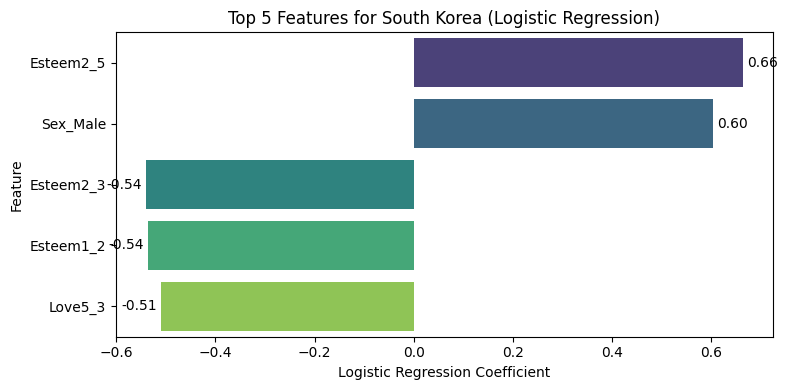

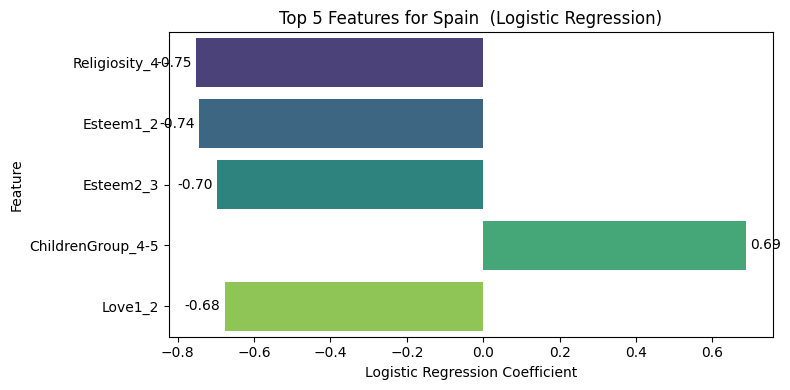

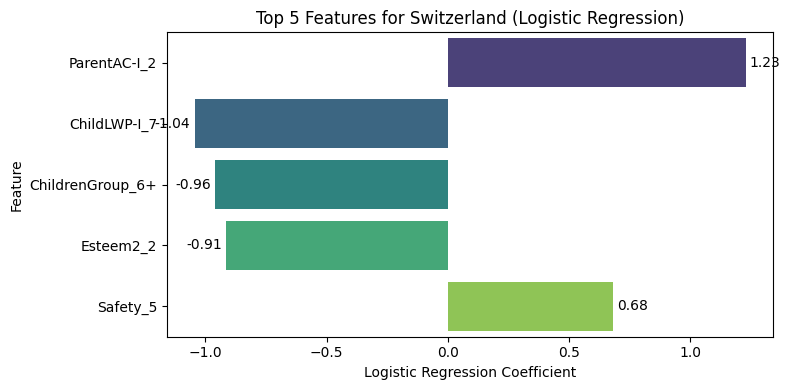

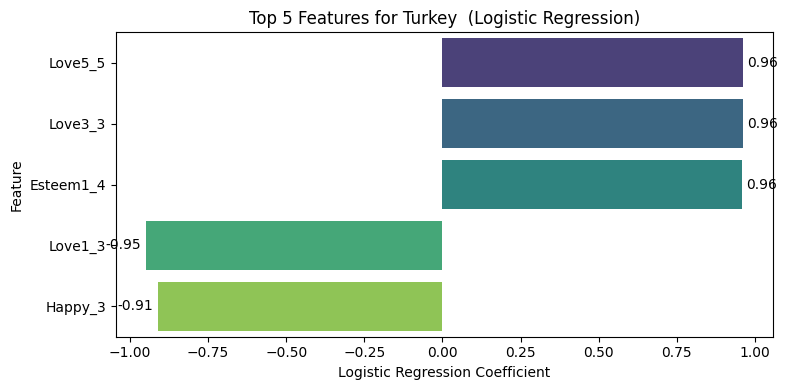

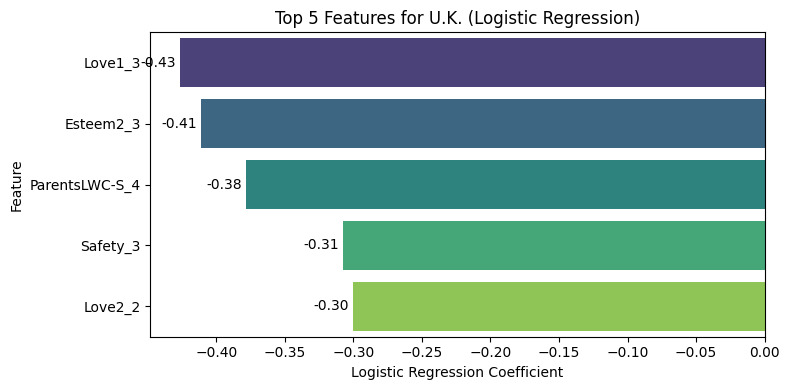

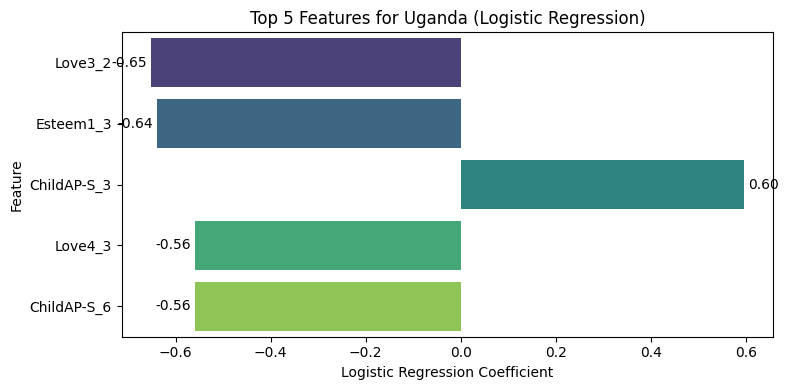

In [ ]:
# 4. Per-Country Top 5 Features for Marital Satisfaction (All Features - Logistic Regression) ===
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Binary‐encode marital satisfaction
y_bin = (df[best_ms].cat.codes >= 4).astype(int)

# 2) List of countries
countries = (df['Country'].cat.categories
             if df['Country'].dtype.name=='category'
             else df['Country'].unique())

# 3) For each country…
for country in countries:
    mask  = df['Country'] == country
    X_sub = X_encoded.loc[mask, all_features]   # <-- use all_features here
    y_sub = y_bin.loc[mask]

    if y_sub.nunique() < 2:
        print(f"Skipping {country!r}: only one class present")
        continue

    # 4) Scale
    scaler       = StandardScaler()
    X_sub_scaled = scaler.fit_transform(X_sub)

    # 5) Fit Logistic Regression
    model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for potential small datasets
    model.fit(X_sub_scaled, y_sub)

    # 6) Grab top 5 by absolute coefficient
    coefs   = model.coef_[0]
    top_idx = np.argsort(np.abs(coefs))[::-1][:5]
    top5    = [(all_features[i], coefs[i]) for i in top_idx]  # <-- index into all_features
    top5_df = pd.DataFrame(top5, columns=['Feature','Logistic_Regression_Coefficient'])

    # 7) Plot
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=top5_df, y='Feature', x='Logistic_Regression_Coefficient', palette='viridis')
    plt.title(f"Top 5 Features for {country} (Logistic Regression)")
    plt.xlabel("Logistic Regression Coefficient")
    plt.ylabel("Feature")
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
    plt.tight_layout()
    plt.show()

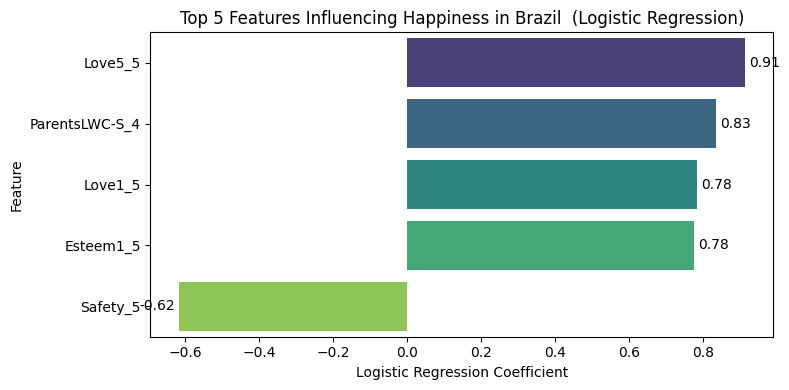

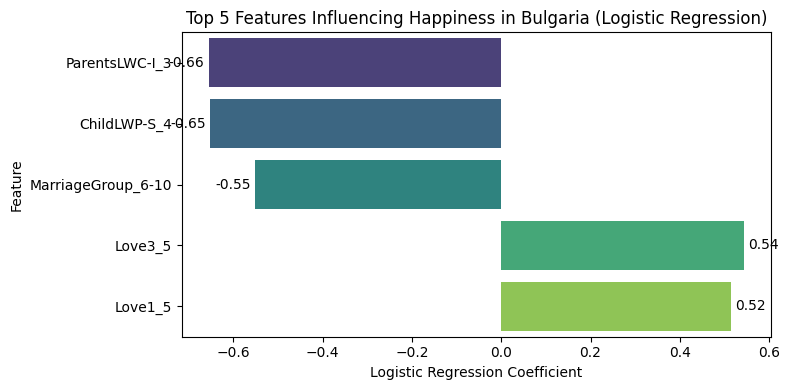

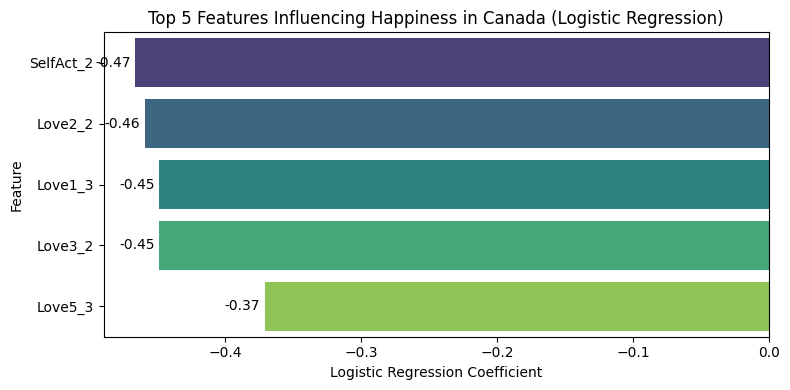

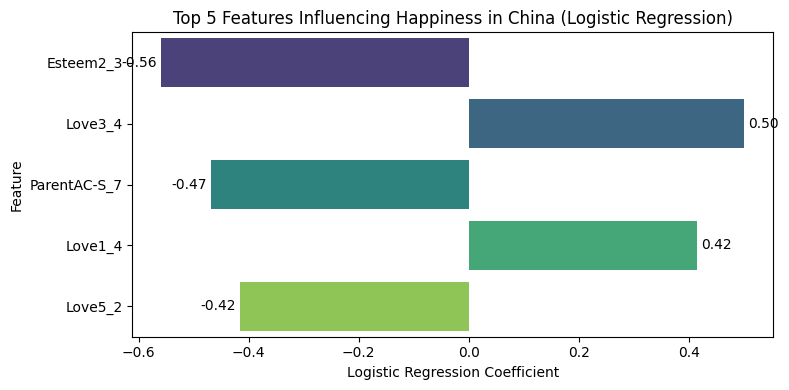

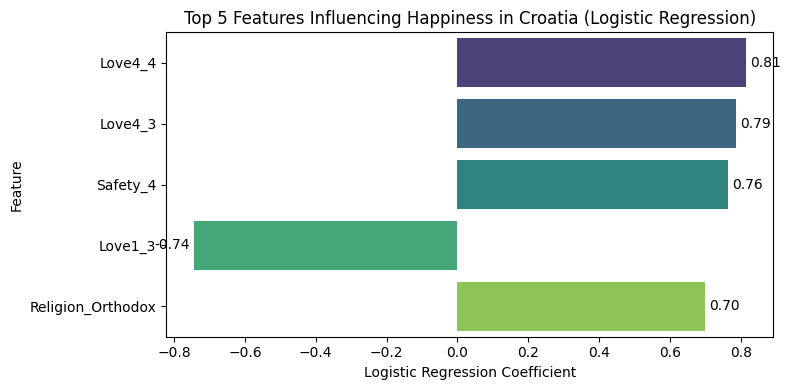

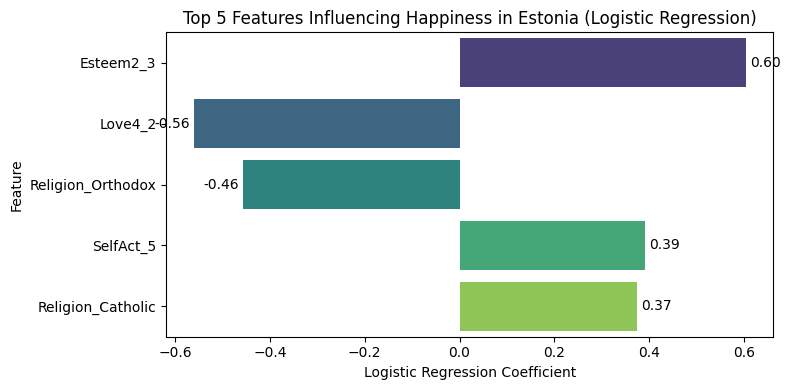

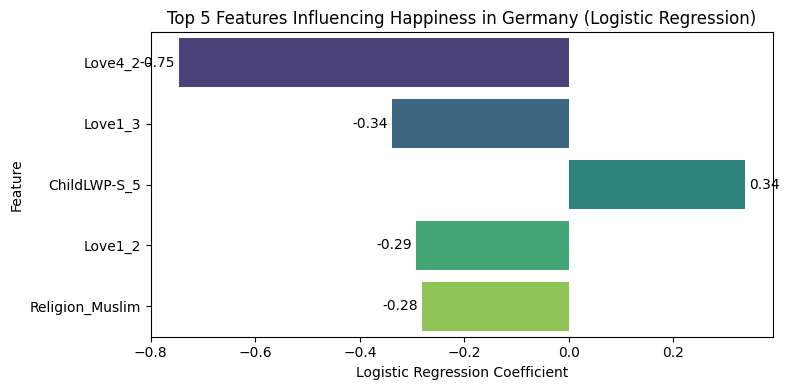

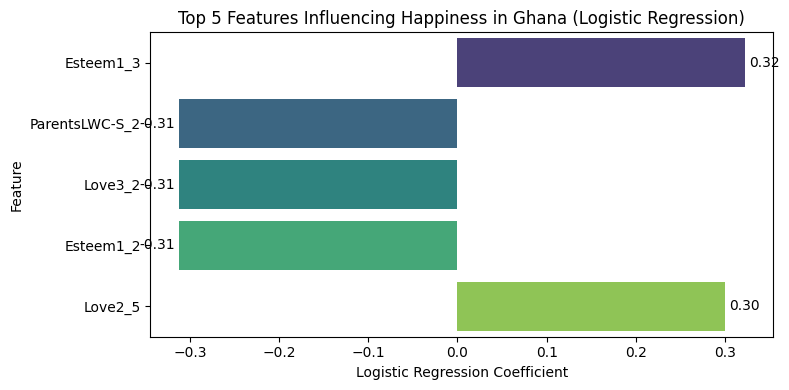

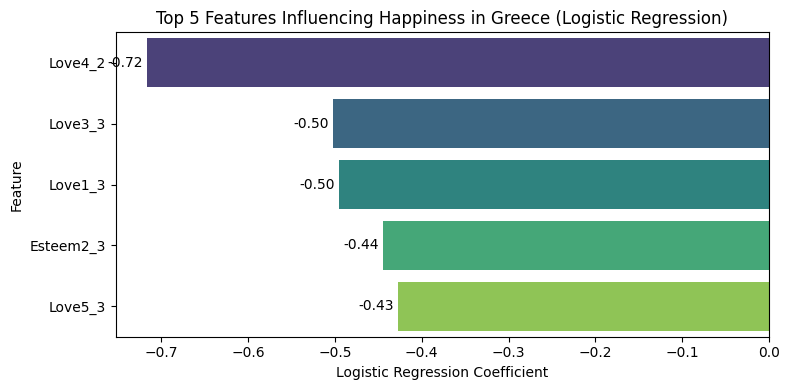

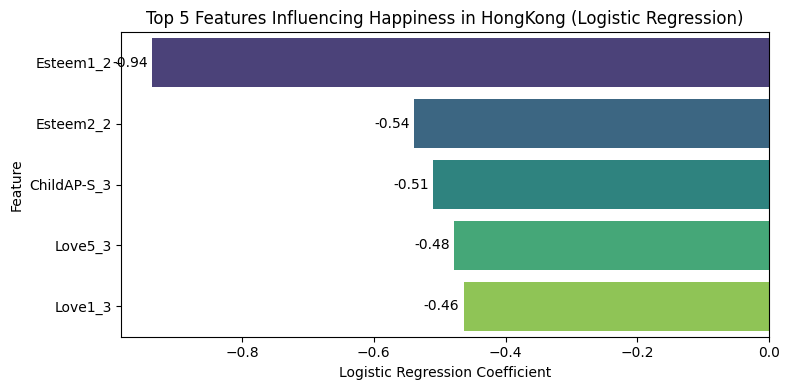

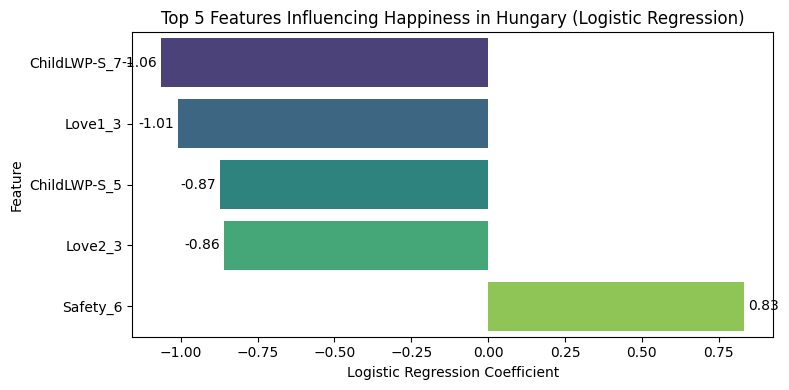

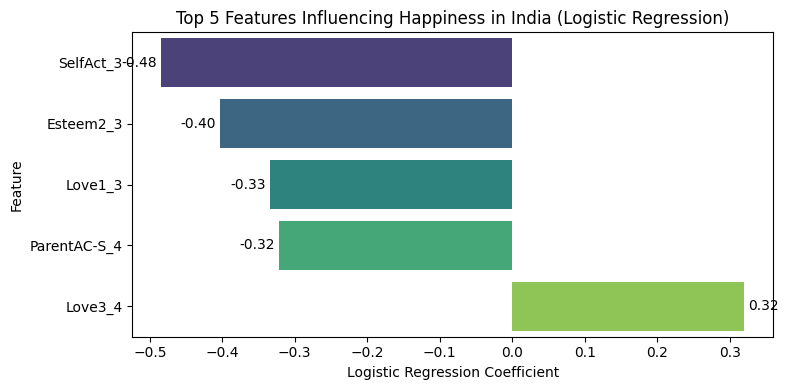

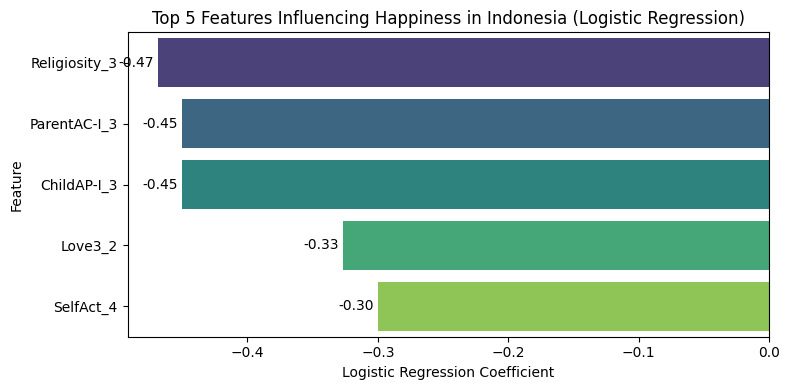

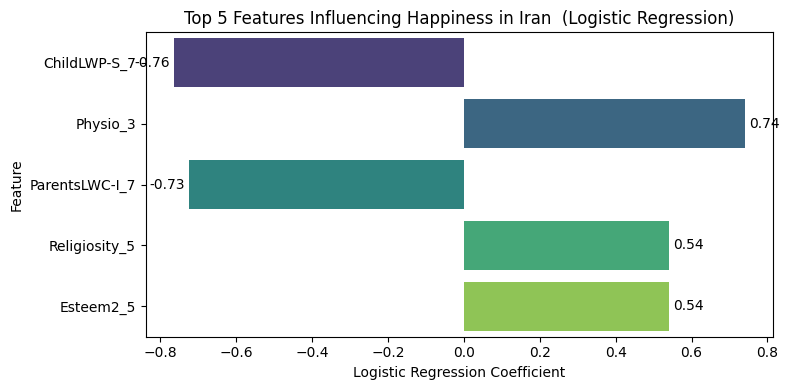

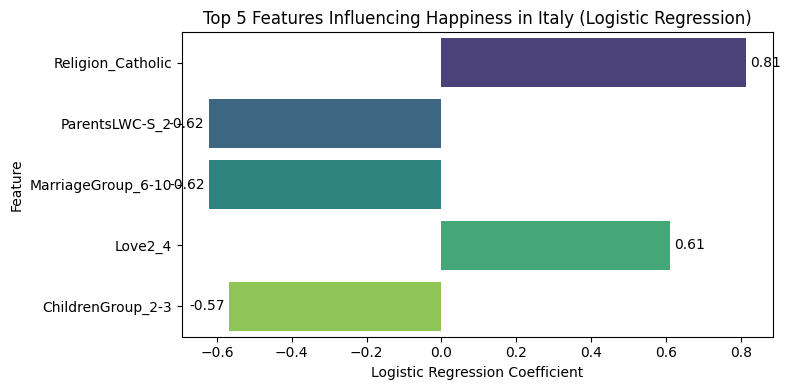

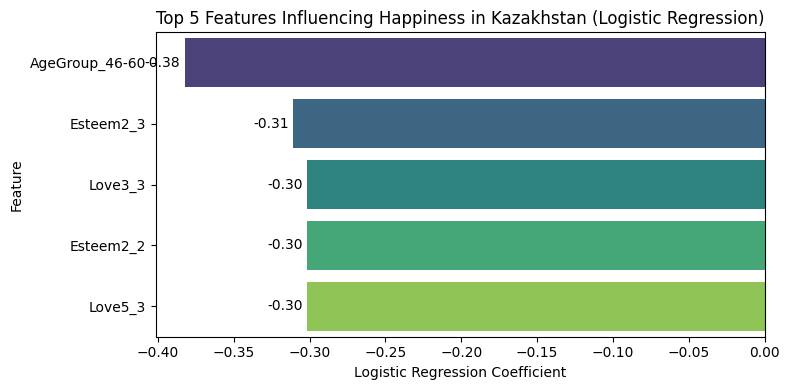

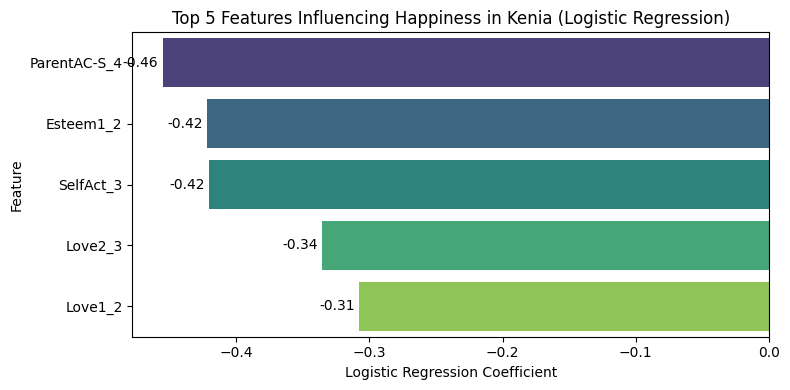

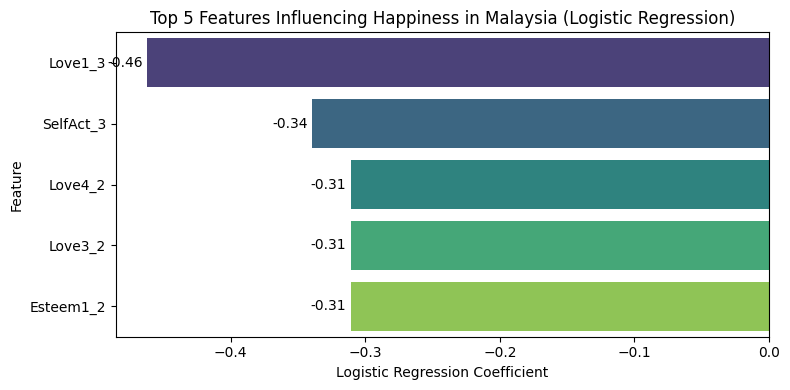

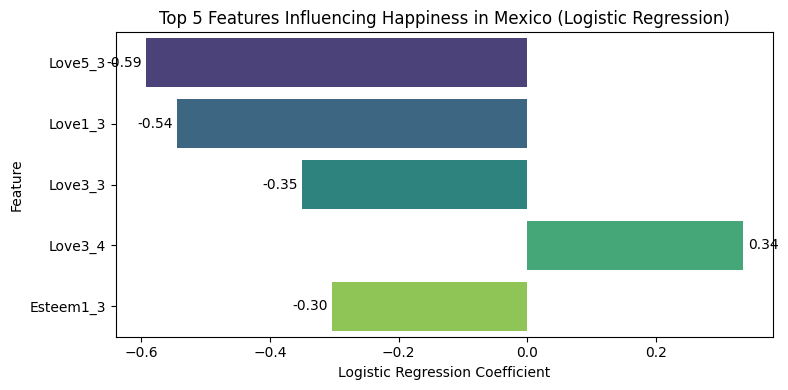

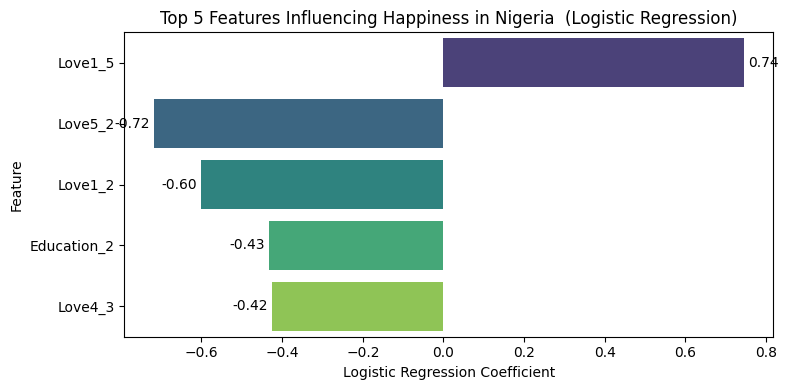

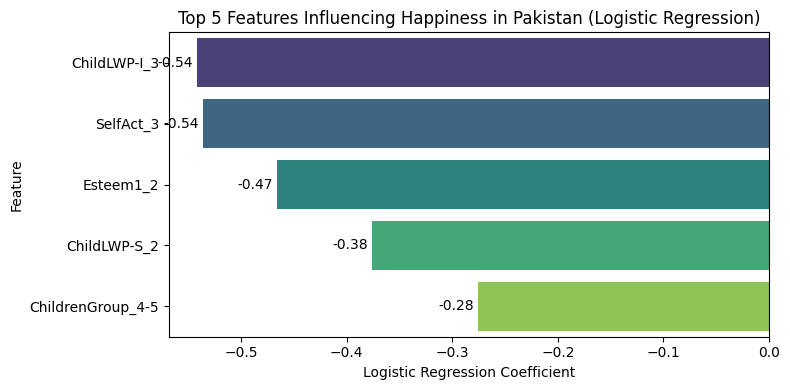

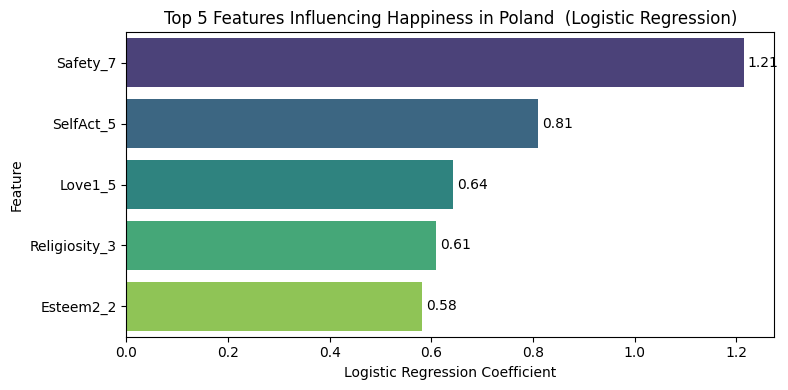

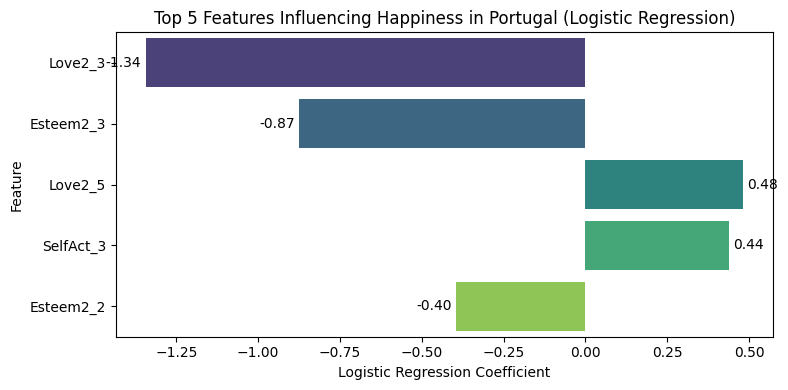

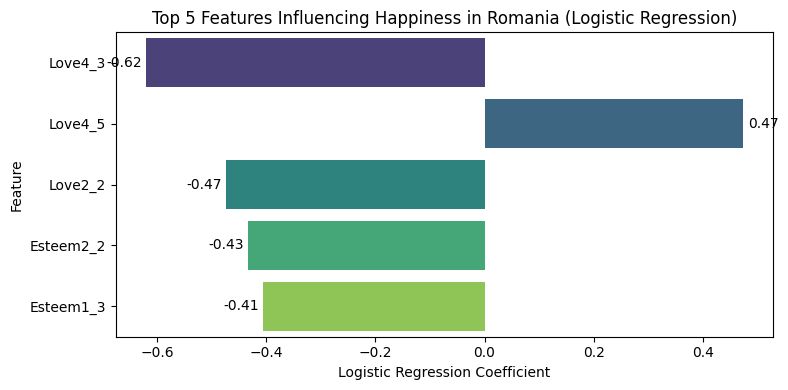

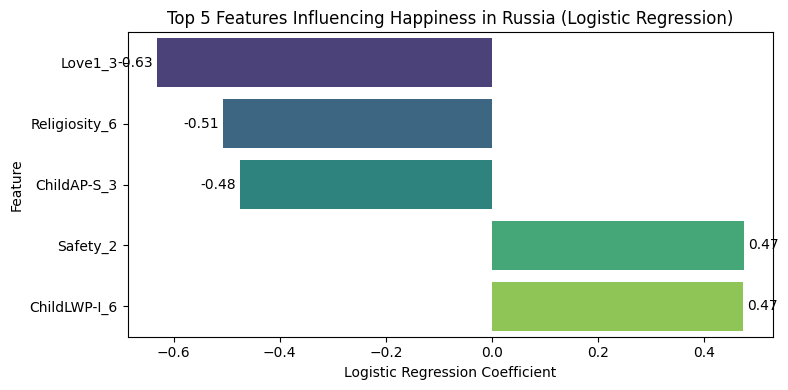

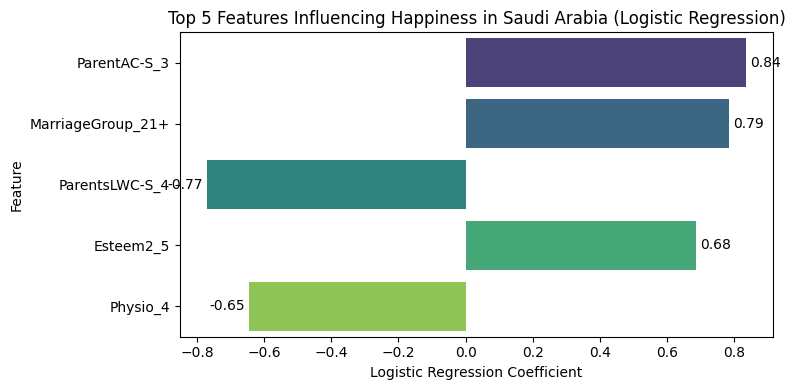

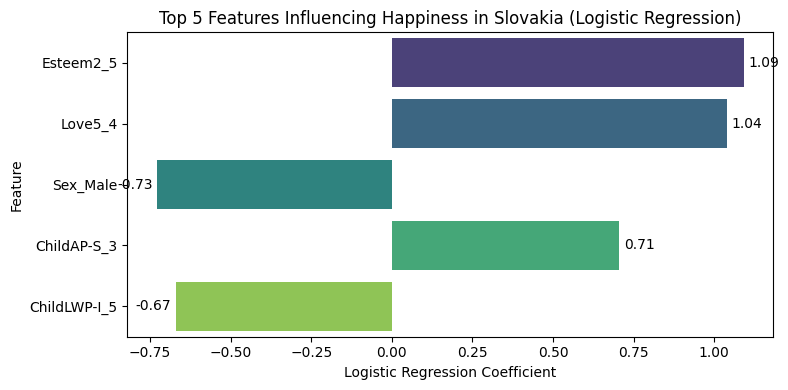

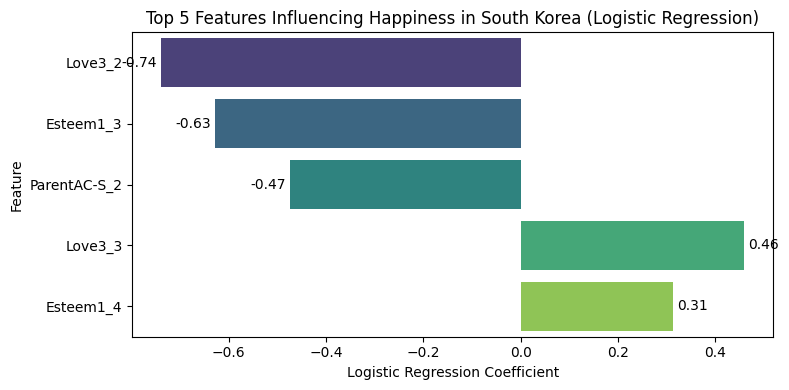

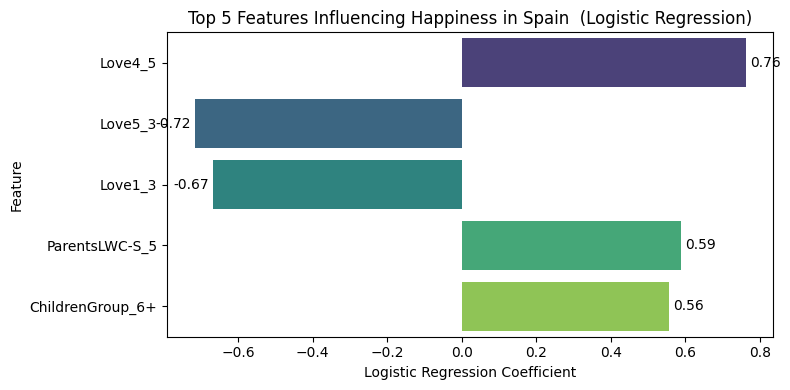

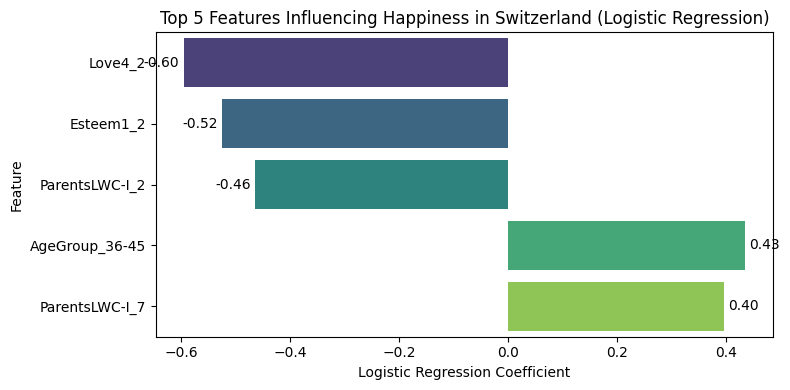

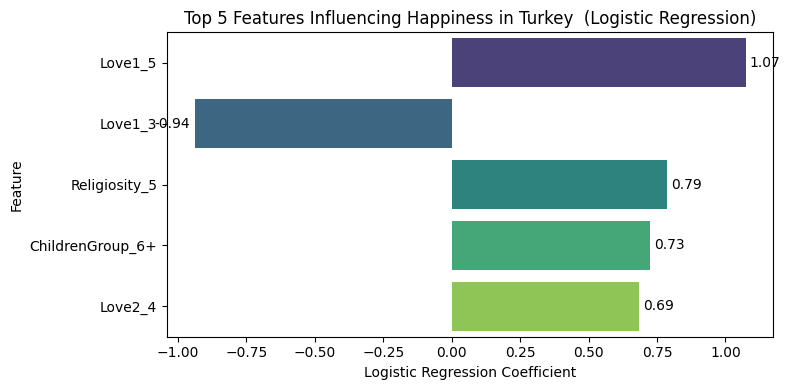

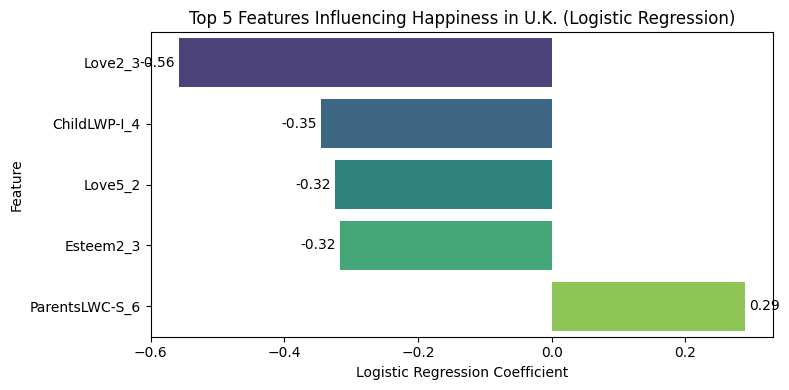

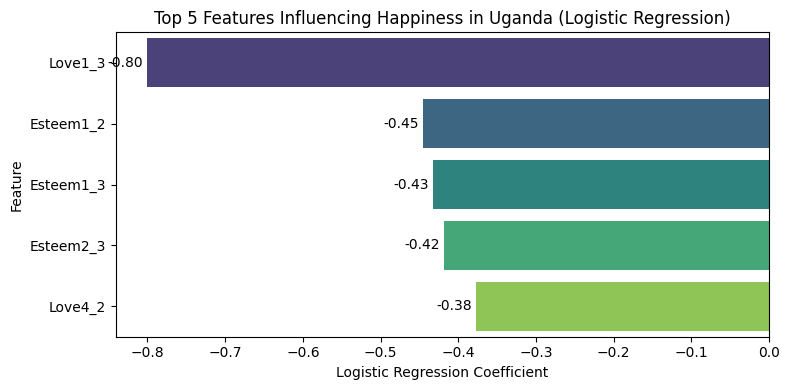

In [ ]:
# Per-Country Top 5 Features for Happiness (All Features, excluding Happy inputs - Logistic Regression) ===
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Binary‐encode happiness: codes ≥3 → “high”
y_happy = (df['Happy'].cat.codes >= 3).astype(int)

# 2) Drop any “Happy” dummies from your feature list
features_for_happy = [f for f in all_features if not f.startswith('Happy')]

# 3) List of countries
countries = (df['Country'].cat.categories
             if df['Country'].dtype.name=='category'
             else df['Country'].unique())

# 4) Loop through each country
for country in countries:
    mask  = df['Country'] == country
    X_sub = X_encoded.loc[mask, features_for_happy]
    y_sub = y_happy.loc[mask]

    # skip if only one class present
    if y_sub.nunique() < 2:
        print(f"Skipping {country!r}: only one happiness class present")
        continue

    # 5) Scale this country’s data
    scaler       = StandardScaler()
    X_sub_scaled = scaler.fit_transform(X_sub)

    # 6) Fit Logistic Regression
    model = LogisticRegression(random_state=42, solver='liblinear') # Using liblinear for potential small datasets
    model.fit(X_sub_scaled, y_sub)

    # 7) Extract top 5 by absolute coefficient
    coefs   = model.coef_[0]
    top_idx = np.argsort(np.abs(coefs))[::-1][:5]
    top5    = [(features_for_happy[i], coefs[i]) for i in top_idx]
    top5_df = pd.DataFrame(top5, columns=['Feature','Logistic_Regression_Coefficient'])

    # 8) Plot
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=top5_df, y='Feature', x='Logistic_Regression_Coefficient', palette='viridis')
    plt.title(f"Top 5 Features Influencing Happiness in {country} (Logistic Regression)")
    plt.xlabel("Logistic Regression Coefficient")
    plt.ylabel("Feature")
    # annotate each bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3)
    plt.tight_layout()
    plt.show()

## 4. Knowledge Evaluation Report (Sections e & f)

This section details the experiments conducted to evaluate the effectiveness of different feature sets and target variable granularities on model performance, specifically using Logistic Regression. The results are presented and discussed, highlighting key findings regarding factors influencing marital satisfaction and happiness.

**e. Evaluation: Experiments Conducted, Evaluation Metrics, Comparisons, etc.**

To gain deeper insights into the relationships within the data and identify influential features, several experiments were conducted using Logistic Regression. This model was chosen for its interpretability, allowing us to examine the coefficients to understand the direction and magnitude of feature impact.

The experiments focused on the following aspects:

1.  **Feature Group Comparison:** The performance of Logistic Regression was evaluated using three different sets of features:
    *   **All Features:** Utilizing the complete set of one-hot encoded features derived from the data preprocessing and feature engineering steps.
    *   **Top 10 Features:** Using the top 10 most important features identified earlier using a Random Forest Classifier.
    *   **Top 3 Features:** Using the top 3 most important features identified earlier.

    This experiment aimed to understand how restricting the feature set based on importance impacts model performance and whether a smaller set of key features could achieve comparable results.

2.  **Scaling Comparison on Top-10 Features:** Using the top 10 features, the impact of different target variable granularities on Logistic Regression performance was assessed. The target variable, marital satisfaction (MS1), was represented in three ways:
    *   **7-level:** The original 7-point ordinal scale (0-6).
    *   **5-level:** A collapsed 5-level scale where extreme categories were merged.
    *   **Binary:** A binary classification where marital satisfaction was categorized as low (0-3) or high (4-6).

    This experiment explored whether simplifying the target variable makes the prediction task easier for the model and improves performance, particularly relevant given the class imbalance in the original 7-level scale.

3.  **Global Top Features (Best Scaling):** Using the best performing target granularity identified in the scaling comparison (binary), the top 10 most influential global features on marital satisfaction were identified based on the Logistic Regression coefficients trained on all features. The absolute values of the coefficients were used to rank importance, and the sign of the coefficient indicates the direction of the relationship (positive for increasing satisfaction, negative for decreasing).

4.  **Global Top Features for Happiness (Binary, excluding Happy inputs):** Similar to the above, the top 10 global features influencing happiness were identified using a binary happiness target (codes >= 3 as "high"). The 'Happy' features themselves were excluded from the input features to avoid circularity and understand what *other* factors contribute to happiness.

5.  **Per-Country Top 5 Features:** To investigate potential regional differences, the top 5 features influencing both binary marital satisfaction and binary happiness were identified for each individual country. This localized analysis helps reveal if the key drivers of satisfaction and happiness vary geographically.

The primary evaluation metrics used were:

*   **Accuracy:** The overall proportion of correctly predicted instances.
*   **F1-weighted:** The weighted average of precision and recall, a suitable metric for multi-class or imbalanced datasets as it considers the contribution of each class.
*   **ROC_AUC:** The Area Under the Receiver Operating Characteristic Curve, used specifically for the binary classification tasks, measuring the model's ability to distinguish between the two classes.

**f. Results and Discussion: Compile results generated (tables, charts, etc.) and discuss the outcomes and findings**

The experiments yielded valuable insights into the factors associated with marital satisfaction and happiness. The results are summarized below, referencing the outputs from the executed code cells.

**Feature Group Comparison (Logistic Regression):**

| Feature\_Group | Accuracy | F1\_weighted |
|----------------|----------|--------------|
| all\_features  | 0.521591 | 0.494831     |
| top10\_features| 0.484659 | 0.439797     |
| top3\_features | 0.460795 | 0.393679     |

*Discussion:* When comparing the performance of Logistic Regression across different feature groups for the multi-class marital satisfaction prediction, using all available features resulted in the highest accuracy and F1-weighted score. However, the performance did not drop drastically when using only the top 10 features, suggesting that these features capture a significant portion of the predictive information. The performance with only the top 3 features was noticeably lower, indicating that while the top features are important, a slightly larger set is needed for better prediction in this multi-class scenario.

**Scaling Comparison on Top-10 Features (Logistic Regression):**

| Granularity | Accuracy | F1\_weighted | ROC\_AUC |
|-------------|----------|--------------|----------|
| 7-level     | 0.4851   | 0.4400       | NaN      |
| 5-level     | 0.7017   | 0.6470       | NaN      |
| binary      | 0.8572   | 0.9189       | 0.8442   |

*Discussion:* This comparison clearly demonstrates the impact of target variable granularity on model performance, especially in the presence of class imbalance. The model performed significantly better on the simplified binary target (high vs. low satisfaction), achieving a much higher F1-weighted score and accuracy. The 5-level granularity also showed improvement over the original 7-level scale. This finding justifies the use of the binary target for subsequent analyses focused on identifying influential features, as it provides a clearer signal for the model to learn from, despite the loss of some nuance from the original scale. The high ROC_AUC for the binary case indicates good discriminatory power.

**Top 10 Global Features (Binary Marital Satisfaction, All Features - Logistic Regression):**

| Feature         | Logistic\_Regression\_Coefficient |
|-----------------|-----------------------------------|
| Esteem1\_5      | 0.8374                            |
| Esteem2\_5      | 0.8238                            |
| Esteem1\_4      | 0.8090                            |
| Love1\_5        | 0.7579                            |
| Esteem2\_4      | 0.5522                            |
| Love1\_4        | 0.4908                            |
| Love4\_5        | 0.4765                            |
| Love4\_4        | 0.4067                            |
| ChildAP-S\_6    | -0.3943                           |
| ChildAP-S\_7    | -0.3782                           |

*Discussion:* The top global features for marital satisfaction are strongly dominated by aspects of Esteem and Love, particularly the higher levels (coded as 4 and 5 after reverse coding). Features like 'Esteem1\_5' (representing the highest level of self-esteem based on achievement) and 'Esteem2\_5' (highest level of self-esteem based on social recognition) have the largest positive coefficients, indicating a strong positive association with high marital satisfaction. Similarly, different facets of love ('Love1', 'Love4') at higher levels are also significant positive predictors. Interestingly, higher levels of 'ChildAP-S' (Child's ability to provide for the family - Solidarity dimension) show negative coefficients, suggesting that in this dataset, respondents who reported that children are highly capable of providing for the family were less likely to report high marital satisfaction. This might warrant further investigation into the cultural context or specific interpretations of this question.

**Top 10 Global Features for Happiness (Binary Logistic Regression):**

| Feature     | Logistic\_Regression\_Coefficient |
|-------------|-----------------------------------|
| Love1\_5    | 0.7900                            |
| Love4\_5    | 0.5661                            |
| Esteem1\_5  | 0.5258                            |
| Physio\_4   | 0.5038                            |
| Love2\_5    | 0.4610                            |
| Love4\_4    | 0.4005                            |
| Love1\_4    | 0.3936                            |
| Physio\_3   | 0.3763                            |
| Physio\_5   | 0.3699                            |
| Education\_5| 0.3577                            |

*Discussion:* When looking at factors influencing general happiness (excluding the direct 'Happy' inputs), different dimensions of 'Love' are the most prominent features. 'Love1\_5' (highest level of love related to romantic/partner love) has the largest positive coefficient, indicating its strong association with higher happiness. Other love-related features ('Love4', 'Love2') also appear in the top 10. Notably, different levels of 'Physio' (Physiological needs satisfaction) also show positive associations, suggesting that meeting basic physiological needs is important for happiness. The highest level of 'Education' ('Education\_5') also has a positive coefficient, implying that higher education levels are associated with greater happiness. This analysis reveals that while esteem is highly linked to marital satisfaction, love and basic needs satisfaction play a more central role in general happiness according to this data and model.

**Per-Country Top 5 Features:**

The per-country analysis (visualized in the numerous plots generated) revealed significant variations in the top features influencing marital satisfaction and happiness across different countries. While some features like certain levels of 'Esteem', 'Love', and 'Physio' appeared frequently, their relative importance and the specific levels that were most influential differed from country to country. This highlights the importance of considering cultural and societal contexts when examining factors related to marital satisfaction and happiness. For example, in some countries, specific religious affiliations or aspects of parent-child relationships (both solidarity and individualism dimensions) appeared as top features, while they were less prominent globally. This country-specific analysis provides nuanced insights that a global model might obscure.

In summary, the knowledge evaluation phase successfully identified key features associated with marital satisfaction and happiness, validated the use of a binary target for better model performance in this imbalanced dataset, and highlighted the significant variations in feature importance across different countries. These findings provide a deeper understanding of the underlying factors and can inform further analysis or potential interventions.

## Slide 1: Knowledge Evaluation - Evaluation

*   **Goal:** Understand which features and target granularities work best for predicting marital satisfaction and happiness.
*   **Model Used:** Logistic Regression (Interpretable coefficients).
*   **Experiments:**
    *   Comparing different Feature Groups (All, Top 10, Top 3) for predicting multi-class marital satisfaction.
    *   Comparing different Target Granularities (7-level, 5-level, Binary) using Top 10 features.
    *   Identifying Global Top Features for Binary Marital Satisfaction.
    *   Identifying Global Top Features for Binary Happiness (excluding 'Happy' inputs).
    *   Identifying Per-Country Top 5 Features for Binary Marital Satisfaction and Happiness.
*   **Evaluation Metrics:**
    *   Accuracy (Overall correct predictions)
    *   F1-weighted (Handles class imbalance, multi-class)
    *   ROC_AUC (Binary classification performance)

## Slide 2: Knowledge Evaluation - Results & Discussion

*   **Feature Group Comparison:**
    *   "All Features" performed best, but "Top 10 Features" were very close, showing key features are impactful.
    *   Reducing to "Top 3 Features" significantly lowered performance (for multi-class).
*   **Target Granularity:**
    *   Binary target (High vs. Low Satisfaction/Happiness) significantly outperformed 7-level and 5-level.
    *   Justifies using binary target for identifying influential features.
*   **Global Top Features (Marital Satisfaction - Binary):**
    *   Strongest predictors: High levels of **Esteem** and **Love**.
    *   Unexpected: Higher 'Child's ability to provide' (Solidarity) negatively associated with high satisfaction.
*   **Global Top Features (Happiness - Binary):**
    *   Strongest predictors: Different facets and high levels of **Love**.
    *   Also important: **Physiological Needs** and **Education**.
*   **Per-Country Insights:**
    *   Top features **vary significantly** by country.
    *   Highlights need to consider cultural context.

## Slide 1: Knowledge Evaluation - Evaluation

*   **Goal:** Understand which features and target granularities work best for predicting marital satisfaction and happiness.
*   **Model Used:** Logistic Regression (Interpretable coefficients).
*   **Target Variable:** Marital Satisfaction (originally 7 levels) and Happiness (originally 7 levels).
*   **Key Consideration:** Class imbalance in the target variables influenced the exploration of different granularities.
*   **Experiments:**
    *   Comparing different Feature Groups (All, Top 10, Top 3) for predicting multi-class marital satisfaction.
    *   Comparing different Target Granularities (7-level, 5-level, Binary) using Top 10 features.
    *   Identifying Global Top Features for Binary Marital Satisfaction.
    *   Identifying Global Top Features for Binary Happiness (excluding 'Happy' inputs).
    *   Identifying Per-Country Top 5 Features for Binary Marital Satisfaction and Happiness.
*   **Evaluation Metrics:**
    *   Accuracy (Overall correct predictions)
    *   F1-weighted (Handles class imbalance, multi-class)
    *   ROC_AUC (Binary classification performance)